# Multi-drone swarm controller

This notebook is the Python/DDS controller for `godot/Multirotor_multiple/world_swarm.tscn`.
Godot simulates drones and publishes UI/state topics. Python reads those topics, computes one local target per active drone, applies a small Boids-style collision-avoidance offset, then publishes namespaced motor forces.


## Imports


In [79]:
import sys
sys.path.append("../../")

import itertools
import math

from lib.data.dataplot import *
from lib.dds.dds import *
from lib.utils.time import *
from lib.system.controllers import *
from lib.system.trajectory import *

## Configuration


In [80]:
MIN_DRONES = 1
MAX_DRONES = 6
CURRENT_DRONES = 4
CURRENT_DRONES_TOPIC = "current_drones"
LEGACY_DRONE_COUNT_TOPIC = "drone_count"
HOVER_ALTITUDE = 1.0
HOVER_FORCE_PER_MOTOR = 2.5
MIN_MOTOR_FORCE = 0.0
MAX_MOTOR_FORCE = 8.0
DRONE_CENTER_SAFE_DISTANCE = 0.8
FORMATION_SPACING = 1.4
RUN_SECONDS = 60
MIN_DELTA_T = 0.0001

FORMATION_NONE = 0
FORMATION_LINE = 1
FORMATION_TRIANGLE = 2
FORMATION_SQUARE = 3
FORMATION_CIRCLE = 4

FORMATION_NAMES = {
    FORMATION_NONE: "NONE",
    FORMATION_LINE: "LINE",
    FORMATION_TRIANGLE: "TRIANGLE",
    FORMATION_SQUARE: "SQUARE",
    FORMATION_CIRCLE: "CIRCLE",
}

BOIDS_MODE_NONE = 0
BOIDS_MODE_SEPARATION = 1
BOIDS_MODE_PREDICTIVE = 2

STATE_NAMES = ["X", "Y", "Z", "TX", "TY", "TZ", "VX", "VY", "VZ", "WX", "WY", "WZ"]
FORCE_NAMES = ["f1", "f2", "f3", "f4"]
BOIDS_DEBUG_FLOAT_NAMES = [
    "boids_x", "boids_y", "boids_length", "boids_safe_distance",
    "base_target_x", "base_target_y", "base_target_z",
    "target_x", "target_y", "target_z", "target_distance",
]
BOIDS_DEBUG_INT_NAMES = ["boids_active", "boids_neighbors", "boids_mode"]
FORMATION_ORIGIN = {"x": 0.0, "y": 0.0, "z": HOVER_ALTITUDE}
PRIMARY_EVIDENCE_DRONE_ID = 0

BOIDS_ENABLED = True
BOIDS_NEIGHBOR_RADIUS = 2.0
BOIDS_SEPARATION_RADIUS = DRONE_CENTER_SAFE_DISTANCE
BOIDS_SEPARATION_WEIGHT = 1.6
BOIDS_ALIGNMENT_WEIGHT = 0.0
BOIDS_COHESION_WEIGHT = 0.0
BOIDS_LOOKAHEAD_SECONDS = 1.0
BOIDS_PREDICTIVE_WEIGHT = 0.8
BOIDS_SIDESTEP_WEIGHT = 0.35
BOIDS_MAX_TARGET_OFFSET = 1.0
BOIDS_APPLY_THRESHOLD = 0.05
BOIDS_TARGET_INTENT_SPEED = 0.8
BOIDS_SEPARATION_PROGRESS_STEP = 0.4
BOIDS_SEPARATION_SIDESTEP_STEP = 0.3

FORMATION_TRANSITION_TARGET_SPEED = 0.7
FORMATION_PATH_SAFE_DISTANCE = 0.9
FORMATION_PATH_CROSSING_PENALTY = 50.0

SWARM_MOVEMENT_ENABLED = True
SWARM_MOVEMENT_REPEAT = True
SWARM_MOVEMENT_SPEED = 0.35
SWARM_MOVEMENT_ACCEL = 0.7
SWARM_MOVEMENT_DECEL = 0.7
SWARM_MOVEMENT_RADIUS = 0.5
SWARM_TAKEOFF_HOLD_SECONDS = 2.0
SMALL_DISTANCE = 0.000001


## Basic Helpers


In [81]:
def validate_startup_settings():
    if MIN_DRONES != 1:
        raise ValueError("MIN_DRONES must stay at 1 for the supported range")
    if MAX_DRONES != 6:
        raise ValueError("MAX_DRONES must stay at 6 for the supported range")
    if CURRENT_DRONES < MIN_DRONES or CURRENT_DRONES > MAX_DRONES:
        raise ValueError("CURRENT_DRONES must be between MIN_DRONES and MAX_DRONES")
    if CURRENT_DRONES != 4:
        raise ValueError("CURRENT_DRONES should start at 4 while supporting 1..6")
    if DRONE_CENTER_SAFE_DISTANCE <= 0:
        raise ValueError("DRONE_CENTER_SAFE_DISTANCE must be positive")
    if HOVER_FORCE_PER_MOTOR <= 0:
        raise ValueError("HOVER_FORCE_PER_MOTOR must be positive")
    if MIN_MOTOR_FORCE < 0 or MAX_MOTOR_FORCE <= MIN_MOTOR_FORCE:
        raise ValueError("Motor force limits must be nonnegative and ordered")
    if FORMATION_SPACING < DRONE_CENTER_SAFE_DISTANCE:
        raise ValueError("FORMATION_SPACING should not be smaller than the drone safety distance")
    if BOIDS_SEPARATION_RADIUS <= 0:
        raise ValueError("BOIDS_SEPARATION_RADIUS must be positive")
    if BOIDS_NEIGHBOR_RADIUS < BOIDS_SEPARATION_RADIUS:
        raise ValueError("BOIDS_NEIGHBOR_RADIUS should be at least the separation radius")


def topic(drone_id, name):
    return f"D{drone_id}_{name}"


def safe_value(value, default=0.0):
    return default if value is None else value


def clamp_value(value, minimum, maximum):
    return max(minimum, min(value, maximum))


def zero_vector():
    return {"x": 0.0, "y": 0.0, "z": 0.0}


def horizontal_length(vector):
    return math.sqrt((vector["x"] * vector["x"]) + (vector["y"] * vector["y"]))


def horizontal_add(first, second):
    return {"x": first["x"] + second["x"], "y": first["y"] + second["y"], "z": 0.0}


def horizontal_scale(vector, scale):
    return {"x": vector["x"] * scale, "y": vector["y"] * scale, "z": 0.0}


def horizontal_subtract(first, second):
    return {"x": first["x"] - second["x"], "y": first["y"] - second["y"], "z": 0.0}


def horizontal_dot(first, second):
    return (first["x"] * second["x"]) + (first["y"] * second["y"])


def horizontal_velocity(state):
    return {"x": state["vx"], "y": state["vy"], "z": 0.0}


def horizontal_normalize(vector):
    length = horizontal_length(vector)
    if length <= SMALL_DISTANCE:
        return zero_vector()
    return {"x": vector["x"] / length, "y": vector["y"] / length, "z": 0.0}


def horizontal_clamp(vector, max_length):
    length = horizontal_length(vector)
    if length <= max_length or length <= SMALL_DISTANCE:
        return vector
    return horizontal_scale(vector, max_length / length)


def horizontal_delta(from_state, to_state):
    return {
        "x": to_state["x"] - from_state["x"],
        "y": to_state["y"] - from_state["y"],
        "z": 0.0,
    }


def distance_to_target(state, target):
    dx = target["x"] - state["x"]
    dy = target["y"] - state["y"]
    dz = target["z"] - state["z"]
    return math.sqrt((dx * dx) + (dy * dy) + (dz * dz))


def horizontal_distance_between(first_state, second_state):
    return horizontal_length(horizontal_delta(first_state, second_state))


def add_horizontal_offset(target, offset):
    return {
        "x": target["x"] + offset["x"],
        "y": target["y"] + offset["y"],
        "z": target["z"],
    }


def minimum_inter_drone_distance(states_by_drone_id):
    active_states = list(states_by_drone_id.values())
    if len(active_states) < 2:
        return None

    minimum_distance = None
    for first_index in range(len(active_states)):
        for second_index in range(first_index + 1, len(active_states)):
            distance = distance_to_target(active_states[first_index], active_states[second_index])
            if minimum_distance is None or distance < minimum_distance:
                minimum_distance = distance
    return minimum_distance


def format_formation_ids(formation_ids):
    return ", ".join(FORMATION_NAMES[formation_id] for formation_id in sorted(formation_ids))


## Formation Target Generation


In [82]:
def hover_target_for(drone_id, drone_count, spacing=FORMATION_SPACING):
    # NONE keeps the old stable hover slots instead of forcing a shape.
    centered_index = drone_id - ((drone_count - 1) * 0.5)
    return {"x": 0.0, "y": centered_index * spacing, "z": 0.0}


def line_offset_for(drone_id, drone_count, spacing=FORMATION_SPACING):
    centered_index = drone_id - ((drone_count - 1) * 0.5)
    return {"x": centered_index * spacing, "y": 0.0, "z": 0.0}


def triangle_offset_for(drone_id, drone_count, spacing=FORMATION_SPACING):
    if drone_count <= 1:
        return zero_vector()

    row = 0
    first_id_in_row = 0
    while drone_id >= first_id_in_row + row + 1:
        first_id_in_row += row + 1
        row += 1

    drones_in_row = row + 1
    column = drone_id - first_id_in_row
    x = (column - ((drones_in_row - 1) * 0.5)) * spacing
    y = (row - 1) * spacing
    return {"x": x, "y": y, "z": 0.0}


def square_offset_for(drone_id, drone_count, spacing=FORMATION_SPACING):
    columns = math.ceil(math.sqrt(max(drone_count, 1)))
    rows = math.ceil(max(drone_count, 1) / columns)
    row = drone_id // columns
    column = drone_id % columns
    x = (column - ((columns - 1) * 0.5)) * spacing
    y = (row - ((rows - 1) * 0.5)) * spacing
    return {"x": x, "y": y, "z": 0.0}


def circle_offset_for(drone_id, drone_count, spacing=FORMATION_SPACING):
    if drone_count <= 1:
        return zero_vector()

    angle = 2.0 * math.pi * drone_id / drone_count
    radius = spacing
    return {"x": radius * math.cos(angle), "y": radius * math.sin(angle), "z": 0.0}


def formation_offset_for(drone_id, drone_count, formation_id, spacing=FORMATION_SPACING):
    if formation_id == FORMATION_LINE:
        return line_offset_for(drone_id, drone_count, spacing)
    if formation_id == FORMATION_TRIANGLE:
        return triangle_offset_for(drone_id, drone_count, spacing)
    if formation_id == FORMATION_SQUARE:
        return square_offset_for(drone_id, drone_count, spacing)
    if formation_id == FORMATION_CIRCLE:
        return circle_offset_for(drone_id, drone_count, spacing)
    return zero_vector()


def formation_origin_or_default(origin=None):
    return FORMATION_ORIGIN if origin is None else origin


def formation_target_for(drone_id, drone_count, formation_id, origin=None, spacing=FORMATION_SPACING):
    origin = formation_origin_or_default(origin)
    if formation_id == FORMATION_NONE:
        offset = hover_target_for(drone_id, drone_count, spacing)
    else:
        offset = formation_offset_for(drone_id, drone_count, formation_id, spacing)

    return {
        "x": origin["x"] + offset["x"],
        "y": origin["y"] + offset["y"],
        "z": origin["z"] + offset["z"],
    }


def compute_formation_targets(active_drone_ids, drone_count, formation_id, origin=None):
    targets = {}
    for drone_id in active_drone_ids:
        targets[drone_id] = formation_target_for(drone_id, drone_count, formation_id, origin)
    return targets


def formation_slots_for(slot_count, formation_id, origin=None):
    return [formation_target_for(slot_id, slot_count, formation_id, origin) for slot_id in range(slot_count)]


## Swarm Movement

These movement classes mirror the professor's `AbstractMovement` pattern, but they move the formation origin instead of a single drone.


In [83]:
class SwarmOrigin:
    def __init__(self, origin):
        self.x = origin["x"]
        self.y = origin["y"]
        self.z = origin["z"]

    def as_dict(self):
        return {"x": self.x, "y": self.y, "z": self.z}


class AbstractMovement:
    def __init__(self, _swarm):
        self.swarm = _swarm

    def start(self):
        pass

    def evaluate(self, delta_t):
        pass

    def movement_done(self):
        return False


class SwarmHoldMovement(AbstractMovement):
    def __init__(self, _swarm, _seconds):
        super().__init__(_swarm)
        self.seconds = _seconds
        self.elapsed = 0.0

    def start(self):
        self.elapsed = 0.0

    def evaluate(self, delta_t):
        self.elapsed += delta_t

    def movement_done(self):
        return self.elapsed >= self.seconds


class SwarmZMovement(AbstractMovement):
    def __init__(self, _swarm, _z_target):
        super().__init__(_swarm)
        self.z_target = _z_target

    def evaluate(self, delta_t):
        self.swarm.z = self.z_target

    def movement_done(self):
        return abs(self.swarm.z - self.z_target) < 0.01


class SwarmXYMovement(AbstractMovement):
    def __init__(self, _swarm, _x_target, _y_target):
        super().__init__(_swarm)
        self.x_target = _x_target
        self.y_target = _y_target
        self.virtual_swarm = StraightLine2DMotion(SWARM_MOVEMENT_SPEED, SWARM_MOVEMENT_ACCEL, SWARM_MOVEMENT_DECEL)

    def start(self):
        self.virtual_swarm.start_motion((self.swarm.x, self.swarm.y), (self.x_target, self.y_target))

    def evaluate(self, delta_t):
        (x_t, y_t) = self.virtual_swarm.evaluate(delta_t)
        self.swarm.x = x_t
        self.swarm.y = y_t

    def movement_done(self):
        dx = self.x_target - self.swarm.x
        dy = self.y_target - self.swarm.y
        return math.sqrt((dx * dx) + (dy * dy)) < 0.03


class SwarmCircleMovement(AbstractMovement):
    def __init__(self, _swarm, _radius):
        super().__init__(_swarm)
        self.radius = _radius
        self.virtual_swarm = VirtualRobot(2.0 * math.pi * _radius, SWARM_MOVEMENT_SPEED, SWARM_MOVEMENT_ACCEL, SWARM_MOVEMENT_DECEL)

    def start(self):
        self.center_x = self.swarm.x - self.radius
        self.center_y = self.swarm.y
        self.virtual_swarm.start(2.0 * math.pi * self.radius)

    def evaluate(self, delta_t):
        self.virtual_swarm.evaluate(delta_t)
        angle = self.virtual_swarm.position() / self.radius
        self.swarm.x = self.center_x + (self.radius * math.cos(angle))
        self.swarm.y = self.center_y + (self.radius * math.sin(angle))

    def movement_done(self):
        return self.virtual_swarm.phase == VirtualRobot.TARGET


class SwarmMovementController:
    def __init__(self, movements, repeat=False):
        self.movements = movements
        self.repeat = repeat
        self.current_index = -1
        self.current_movement = None
        self.start_next_movement()

    def start_next_movement(self):
        if not self.movements:
            self.current_movement = None
            return

        self.current_index += 1
        if self.current_index >= len(self.movements):
            if not self.repeat:
                self.current_movement = None
                return
            self.current_index = 0

        self.current_movement = self.movements[self.current_index]
        self.current_movement.start()

    def evaluate(self, delta_t):
        if self.current_movement is None:
            return

        self.current_movement.evaluate(delta_t)
        if self.current_movement.movement_done():
            self.start_next_movement()


def create_swarm_movements(swarm_origin):
    if not SWARM_MOVEMENT_ENABLED:
        return []

    # Add new swarm movements here; each one moves the formation origin.
    return [
        SwarmHoldMovement(swarm_origin, SWARM_TAKEOFF_HOLD_SECONDS),
        SwarmXYMovement(swarm_origin, 0.8, 0.0),
        SwarmCircleMovement(swarm_origin, SWARM_MOVEMENT_RADIUS),
        SwarmXYMovement(swarm_origin, 0.0, 0.0),
    ]

## Formation Transition Safety

This layer keeps formation changes from assigning obvious crossing paths, then feeds target-intent velocities into Boids so drones can react before they physically meet.


In [84]:
def copy_target(target):
    return {"x": target["x"], "y": target["y"], "z": target["z"]}


def state_as_target(state, z_target):
    return {"x": state["x"], "y": state["y"], "z": z_target}


def point2d(value):
    return (value["x"], value["y"])


def distance_2d(first, second):
    dx = first[0] - second[0]
    dy = first[1] - second[1]
    return math.sqrt((dx * dx) + (dy * dy))


def orientation_2d(a, b, c):
    return ((b[0] - a[0]) * (c[1] - a[1])) - ((b[1] - a[1]) * (c[0] - a[0]))


def on_segment_2d(a, b, c):
    return (
        min(a[0], c[0]) - SMALL_DISTANCE <= b[0] <= max(a[0], c[0]) + SMALL_DISTANCE and
        min(a[1], c[1]) - SMALL_DISTANCE <= b[1] <= max(a[1], c[1]) + SMALL_DISTANCE
    )


def segments_intersect_2d(a, b, c, d):
    first = orientation_2d(a, b, c)
    second = orientation_2d(a, b, d)
    third = orientation_2d(c, d, a)
    fourth = orientation_2d(c, d, b)

    if first * second < 0.0 and third * fourth < 0.0:
        return True
    if abs(first) <= SMALL_DISTANCE and on_segment_2d(a, c, b):
        return True
    if abs(second) <= SMALL_DISTANCE and on_segment_2d(a, d, b):
        return True
    if abs(third) <= SMALL_DISTANCE and on_segment_2d(c, a, d):
        return True
    if abs(fourth) <= SMALL_DISTANCE and on_segment_2d(c, b, d):
        return True
    return False


def point_segment_distance_2d(point, segment_start, segment_end):
    sx = segment_end[0] - segment_start[0]
    sy = segment_end[1] - segment_start[1]
    length_squared = (sx * sx) + (sy * sy)
    if length_squared <= SMALL_DISTANCE:
        return distance_2d(point, segment_start)

    t = ((point[0] - segment_start[0]) * sx + (point[1] - segment_start[1]) * sy) / length_squared
    t = max(0.0, min(1.0, t))
    projection = (segment_start[0] + (t * sx), segment_start[1] + (t * sy))
    return distance_2d(point, projection)


def segment_distance_2d(first_start, first_end, second_start, second_end):
    if segments_intersect_2d(first_start, first_end, second_start, second_end):
        return 0.0

    return min(
        point_segment_distance_2d(first_start, second_start, second_end),
        point_segment_distance_2d(first_end, second_start, second_end),
        point_segment_distance_2d(second_start, first_start, first_end),
        point_segment_distance_2d(second_end, first_start, first_end),
    )


def assignment_cost(active_drone_ids, slot_indexes, slot_targets, states_by_drone_id):
    cost = 0.0
    assigned_targets = {}
    for drone_id, slot_index in zip(active_drone_ids, slot_indexes):
        target = slot_targets[slot_index]
        assigned_targets[drone_id] = target
        if drone_id in states_by_drone_id:
            distance = horizontal_distance_between(states_by_drone_id[drone_id], target)
            cost += distance * distance

    for first_index in range(len(active_drone_ids)):
        for second_index in range(first_index + 1, len(active_drone_ids)):
            first_id = active_drone_ids[first_index]
            second_id = active_drone_ids[second_index]
            if first_id not in states_by_drone_id or second_id not in states_by_drone_id:
                continue

            first_start = point2d(states_by_drone_id[first_id])
            first_end = point2d(assigned_targets[first_id])
            second_start = point2d(states_by_drone_id[second_id])
            second_end = point2d(assigned_targets[second_id])
            clearance = segment_distance_2d(first_start, first_end, second_start, second_end)
            if clearance < FORMATION_PATH_SAFE_DISTANCE:
                shortage = FORMATION_PATH_SAFE_DISTANCE - clearance
                cost += FORMATION_PATH_CROSSING_PENALTY * shortage * shortage

    return cost


def assign_slots_to_drones(active_drone_ids, slot_targets, states_by_drone_id):
    if not active_drone_ids:
        return {}

    best_assignment = None
    best_cost = None
    for slot_indexes in itertools.permutations(range(len(slot_targets)), len(active_drone_ids)):
        cost = assignment_cost(active_drone_ids, slot_indexes, slot_targets, states_by_drone_id)
        if best_cost is None or cost < best_cost:
            best_cost = cost
            best_assignment = slot_indexes

    return {drone_id: slot_index for drone_id, slot_index in zip(active_drone_ids, best_assignment)}


def move_target_toward(current_target, desired_target, max_step):
    delta = horizontal_delta(current_target, desired_target)
    distance = horizontal_length(delta)
    if distance <= max_step or distance <= SMALL_DISTANCE:
        return copy_target(desired_target)

    direction = horizontal_normalize(delta)
    return {
        "x": current_target["x"] + (direction["x"] * max_step),
        "y": current_target["y"] + (direction["y"] * max_step),
        "z": desired_target["z"],
    }


class FormationTransitionManager:
    def __init__(self):
        self.signature = None
        self.assignment_by_drone_id = {}
        self.routed_targets = {}

    def update(self, active_drone_ids, formation_id, formation_origin, states_by_drone_id, delta_t):
        active_drone_ids = sorted(active_drone_ids)
        slot_count = len(active_drone_ids)
        if slot_count == 0:
            self.signature = None
            self.assignment_by_drone_id = {}
            self.routed_targets = {}
            return {}

        signature = (tuple(active_drone_ids), formation_id, slot_count)
        slot_targets = formation_slots_for(slot_count, formation_id, formation_origin)
        if signature != self.signature:
            self.assignment_by_drone_id = assign_slots_to_drones(active_drone_ids, slot_targets, states_by_drone_id)
            self.routed_targets = {}
            for drone_id in active_drone_ids:
                if drone_id in states_by_drone_id:
                    self.routed_targets[drone_id] = state_as_target(states_by_drone_id[drone_id], formation_origin["z"])
                else:
                    self.routed_targets[drone_id] = copy_target(slot_targets[self.assignment_by_drone_id[drone_id]])
            self.signature = signature

        max_step = max(delta_t, MIN_DELTA_T) * FORMATION_TRANSITION_TARGET_SPEED
        targets = {}
        for drone_id in active_drone_ids:
            slot_index = self.assignment_by_drone_id.get(drone_id, active_drone_ids.index(drone_id))
            desired_target = slot_targets[slot_index]
            current_target = self.routed_targets.get(drone_id, state_as_target(states_by_drone_id[drone_id], desired_target["z"]))
            routed_target = move_target_toward(current_target, desired_target, max_step)
            self.routed_targets[drone_id] = routed_target
            targets[drone_id] = routed_target

        for drone_id in list(self.routed_targets.keys()):
            if drone_id not in active_drone_ids:
                self.routed_targets.pop(drone_id, None)

        return targets


def states_with_target_intent(states_by_drone_id, targets_by_drone_id):
    planned_states = {}
    for drone_id, state in states_by_drone_id.items():
        planned_state = dict(state)
        target = targets_by_drone_id.get(drone_id)
        if target is not None:
            delta_to_target = horizontal_delta(state, target)
            direction = horizontal_normalize(delta_to_target)
            if horizontal_length(delta_to_target) > SMALL_DISTANCE:
                planned_state["vx"] = direction["x"] * BOIDS_TARGET_INTENT_SPEED
                planned_state["vy"] = direction["y"] * BOIDS_TARGET_INTENT_SPEED
        planned_states[drone_id] = planned_state
    return planned_states


## Boids Collision Avoidance

This is intentionally small and readable. It does not directly move drones; it only nudges each local target before the low-level PID controller computes motor forces.

The strongest rule is separation. Alignment and cohesion are kept small because formations already define the main swarm shape.

The separation radius is a center-to-center safety distance, not just a mathematical point distance. The predictive rule looks ahead for face-on collisions and adds a lateral sidestep before the drone bodies touch.


In [85]:
def deterministic_away_direction(drone_id, other_drone_id):
    angle = (drone_id + 1) * 1.61803398875 + (other_drone_id + 1) * 0.73
    return {"x": math.cos(angle), "y": math.sin(angle), "z": 0.0}


def sidestep_direction_for(away_direction):
    side = {"x": -away_direction["y"], "y": away_direction["x"], "z": 0.0}
    return horizontal_normalize(side)


def closest_approach_seconds(current_state, other_state):
    relative_position = horizontal_delta(other_state, current_state)
    relative_velocity = horizontal_subtract(horizontal_velocity(current_state), horizontal_velocity(other_state))
    speed_squared = horizontal_dot(relative_velocity, relative_velocity)
    if speed_squared <= SMALL_DISTANCE:
        return 0.0

    closest_time = -horizontal_dot(relative_position, relative_velocity) / speed_squared
    return max(0.0, min(closest_time, BOIDS_LOOKAHEAD_SECONDS))


def predicted_state_after(state, seconds):
    return {
        "x": state["x"] + (state["vx"] * seconds),
        "y": state["y"] + (state["vy"] * seconds),
        "z": state["z"],
        "vx": state["vx"],
        "vy": state["vy"],
    }


def separation_offset_for(drone_id, states_by_drone_id):
    current_state = states_by_drone_id[drone_id]
    offset = zero_vector()

    for other_drone_id, other_state in states_by_drone_id.items():
        if other_drone_id == drone_id:
            continue

        distance = horizontal_distance_between(current_state, other_state)
        if distance >= BOIDS_SEPARATION_RADIUS:
            continue

        away_from_neighbor = horizontal_delta(other_state, current_state)
        if distance <= SMALL_DISTANCE:
            direction = deterministic_away_direction(drone_id, other_drone_id)
        else:
            direction = horizontal_normalize(away_from_neighbor)

        strength = (BOIDS_SEPARATION_RADIUS - max(distance, SMALL_DISTANCE)) / BOIDS_SEPARATION_RADIUS
        offset = horizontal_add(offset, horizontal_scale(direction, strength * BOIDS_SEPARATION_WEIGHT))

    return offset


def predictive_offset_for(drone_id, states_by_drone_id):
    current_state = states_by_drone_id[drone_id]
    offset = zero_vector()

    for other_drone_id, other_state in states_by_drone_id.items():
        if other_drone_id == drone_id:
            continue

        current_distance = horizontal_distance_between(current_state, other_state)
        if current_distance > BOIDS_NEIGHBOR_RADIUS:
            continue

        closest_time = closest_approach_seconds(current_state, other_state)
        predicted_current = predicted_state_after(current_state, closest_time)
        predicted_other = predicted_state_after(other_state, closest_time)
        predicted_distance = horizontal_distance_between(predicted_current, predicted_other)
        if predicted_distance >= BOIDS_SEPARATION_RADIUS or predicted_distance >= current_distance:
            continue

        away_from_neighbor = horizontal_delta(predicted_other, predicted_current)
        if predicted_distance <= SMALL_DISTANCE:
            current_away_from_neighbor = horizontal_delta(other_state, current_state)
            if horizontal_length(current_away_from_neighbor) <= SMALL_DISTANCE:
                direction = deterministic_away_direction(drone_id, other_drone_id)
            else:
                direction = horizontal_normalize(current_away_from_neighbor)
        else:
            direction = horizontal_normalize(away_from_neighbor)

        strength = (BOIDS_SEPARATION_RADIUS - max(predicted_distance, SMALL_DISTANCE)) / BOIDS_SEPARATION_RADIUS
        offset = horizontal_add(offset, horizontal_scale(direction, strength * BOIDS_PREDICTIVE_WEIGHT))
        offset = horizontal_add(offset, horizontal_scale(sidestep_direction_for(direction), strength * BOIDS_SIDESTEP_WEIGHT))

    return offset


def nearby_neighbor_states_for(drone_id, states_by_drone_id):
    current_state = states_by_drone_id[drone_id]
    neighbors = []
    for other_drone_id, other_state in states_by_drone_id.items():
        if other_drone_id == drone_id:
            continue
        if horizontal_distance_between(current_state, other_state) <= BOIDS_NEIGHBOR_RADIUS:
            neighbors.append(other_state)
    return neighbors


def alignment_offset_for(drone_id, states_by_drone_id):
    neighbors = nearby_neighbor_states_for(drone_id, states_by_drone_id)
    if not neighbors:
        return zero_vector()

    average_vx = sum(neighbor["vx"] for neighbor in neighbors) / len(neighbors)
    average_vy = sum(neighbor["vy"] for neighbor in neighbors) / len(neighbors)
    return {"x": average_vx * BOIDS_ALIGNMENT_WEIGHT, "y": average_vy * BOIDS_ALIGNMENT_WEIGHT, "z": 0.0}


def cohesion_offset_for(drone_id, states_by_drone_id):
    neighbors = nearby_neighbor_states_for(drone_id, states_by_drone_id)
    if not neighbors:
        return zero_vector()

    current_state = states_by_drone_id[drone_id]
    center = {
        "x": sum(neighbor["x"] for neighbor in neighbors) / len(neighbors),
        "y": sum(neighbor["y"] for neighbor in neighbors) / len(neighbors),
        "z": current_state["z"],
    }
    toward_center = horizontal_delta(current_state, center)
    return horizontal_scale(toward_center, BOIDS_COHESION_WEIGHT)


def boids_offset_for(drone_id, states_by_drone_id):
    if not BOIDS_ENABLED or drone_id not in states_by_drone_id:
        return zero_vector()

    offset = zero_vector()
    offset = horizontal_add(offset, separation_offset_for(drone_id, states_by_drone_id))
    offset = horizontal_add(offset, predictive_offset_for(drone_id, states_by_drone_id))
    offset = horizontal_add(offset, alignment_offset_for(drone_id, states_by_drone_id))
    offset = horizontal_add(offset, cohesion_offset_for(drone_id, states_by_drone_id))
    return horizontal_clamp(offset, BOIDS_MAX_TARGET_OFFSET)


def compute_boids_offsets(states_by_drone_id):
    offsets = {}
    for drone_id in states_by_drone_id:
        offsets[drone_id] = boids_offset_for(drone_id, states_by_drone_id)
    return offsets


def separation_adjusted_target_for(drone_id, base_target, state, separation_offset, raw_boids_offset):
    away_direction = horizontal_normalize(separation_offset)
    progress = horizontal_delta(state, base_target)

    if horizontal_length(away_direction) > SMALL_DISTANCE:
        movement_into_neighbor = -horizontal_dot(progress, away_direction)
        if movement_into_neighbor > 0.0:
            progress = horizontal_add(progress, horizontal_scale(away_direction, movement_into_neighbor))

        sidestep_direction = sidestep_direction_for(away_direction)
        sidestep_amount = horizontal_dot(raw_boids_offset, sidestep_direction)
        if abs(sidestep_amount) <= BOIDS_APPLY_THRESHOLD:
            sidestep_amount = BOIDS_SEPARATION_SIDESTEP_STEP if drone_id % 2 == 0 else -BOIDS_SEPARATION_SIDESTEP_STEP
        sidestep_amount = clamp_value(
            sidestep_amount,
            -BOIDS_SEPARATION_SIDESTEP_STEP,
            BOIDS_SEPARATION_SIDESTEP_STEP,
        )
        progress = horizontal_add(progress, horizontal_scale(sidestep_direction, sidestep_amount))

    progress = horizontal_clamp(progress, BOIDS_SEPARATION_PROGRESS_STEP)
    local_offset = horizontal_clamp(horizontal_add(separation_offset, progress), BOIDS_MAX_TARGET_OFFSET)
    local_target = {"x": state["x"], "y": state["y"], "z": base_target["z"]}
    return add_horizontal_offset(local_target, local_offset), local_offset


def apply_boids_to_targets(base_targets, states_by_drone_id, avoidance_states_by_drone_id=None):
    if avoidance_states_by_drone_id is None:
        avoidance_states_by_drone_id = states_by_drone_id

    raw_boids_offsets = compute_boids_offsets(avoidance_states_by_drone_id)
    adjusted_targets = {}
    applied_offsets = {}
    boids_modes = {}
    for drone_id, base_target in base_targets.items():
        applied_offset = zero_vector()
        boids_mode = BOIDS_MODE_NONE
        if drone_id not in states_by_drone_id:
            adjusted_targets[drone_id] = base_target
            applied_offsets[drone_id] = applied_offset
            boids_modes[drone_id] = boids_mode
            continue

        raw_boids_offset = raw_boids_offsets.get(drone_id, zero_vector())
        separation_offset = separation_offset_for(drone_id, states_by_drone_id)
        if horizontal_length(separation_offset) > BOIDS_APPLY_THRESHOLD:
            adjusted_target, applied_offset = separation_adjusted_target_for(
                drone_id,
                base_target,
                states_by_drone_id[drone_id],
                separation_offset,
                raw_boids_offset,
            )
            adjusted_targets[drone_id] = adjusted_target
            boids_mode = BOIDS_MODE_SEPARATION
        elif horizontal_length(raw_boids_offset) > BOIDS_APPLY_THRESHOLD:
            applied_offset = horizontal_clamp(raw_boids_offset, BOIDS_MAX_TARGET_OFFSET)
            adjusted_targets[drone_id] = add_horizontal_offset(base_target, applied_offset)
            boids_mode = BOIDS_MODE_PREDICTIVE
        else:
            adjusted_targets[drone_id] = base_target

        applied_offsets[drone_id] = applied_offset
        boids_modes[drone_id] = boids_mode
    return adjusted_targets, applied_offsets, boids_modes

def maximum_boids_offset(boids_offsets):
    if not boids_offsets:
        return 0.0
    return max(horizontal_length(offset) for offset in boids_offsets.values())


## Low-level Multirotor Controller


In [86]:
class Multirotor:

    def __init__(self, x_target=0.0, y_target=0.0, z_target=HOVER_ALTITUDE):
        self.vz_control = PID_Controller(5.0, 10.0, 0.0, 5)
        self.z_control = PID_Controller(2.0, 0.0, 0.0, 2)

        self.w_roll_control = PID_Controller(0.75, 0.3, 0.0075, 2)
        self.roll_control = PID_Controller(1.0, 0.0, 0.0, 2)

        self.w_pitch_control = PID_Controller(0.75, 0.3, 0.0075, 2)
        self.pitch_control = PID_Controller(1.0, 0.0, 0.0, 2)

        self.vy_control = PID_Controller(0.4, 0.01, 0.25, math.radians(30))
        self.y_control = PID_Controller(1.0, 0.0, 0.0, 2.0)

        self.vx_control = PID_Controller(0.4, 0.01, 0.25, math.radians(30))
        self.x_control = PID_Controller(1.0, 0.0, 0.0, 2.0)

        self.z_target = z_target
        self.x_target = x_target
        self.y_target = y_target

        self.vz_target = 0.0
        self.vx_target = 0.0
        self.vy_target = 0.0

    def set_target(self, target):
        self.x_target = target["x"]
        self.y_target = target["y"]
        self.z_target = target["z"]

    def evaluate(self, delta_t, z, vz, x, vx, y, vy, roll, roll_rate, pitch, pitch_rate):
        # The output order matches the four propeller topics D{i}_f1..D{i}_f4.
        self.vz_target = self.z_control.evaluate(delta_t, self.z_target - z)
        altitude_correction = self.vz_control.evaluate(delta_t, self.vz_target - vz)
        f = clamp_value(HOVER_FORCE_PER_MOTOR + altitude_correction, MIN_MOTOR_FORCE, MAX_MOTOR_FORCE)

        self.vy_target = self.y_control.evaluate(delta_t, self.y_target - y)
        self.roll_target = -self.vy_control.evaluate(delta_t, self.vy_target - vy)

        self.vx_target = self.x_control.evaluate(delta_t, self.x_target - x)
        self.pitch_target = self.vx_control.evaluate(delta_t, self.vx_target - vx)

        self.roll_rate_target = self.roll_control.evaluate(delta_t, self.roll_target - roll)
        roll_command = self.w_roll_control.evaluate(delta_t, self.roll_rate_target - roll_rate)

        self.pitch_rate_target = self.pitch_control.evaluate(delta_t, self.pitch_target - pitch)
        pitch_command = self.w_pitch_control.evaluate(delta_t, self.pitch_rate_target - pitch_rate)

        mixed_forces = (
            f + roll_command - pitch_command,
            f - roll_command - pitch_command,
            f - roll_command + pitch_command,
            f + roll_command + pitch_command,
        )
        return tuple(clamp_value(force, MIN_MOTOR_FORCE, MAX_MOTOR_FORCE) for force in mixed_forces)

## DDS Read/Write Helpers


In [87]:
def subscribe_topics_for(max_drones):
    topics = ["start", "tick", CURRENT_DRONES_TOPIC, LEGACY_DRONE_COUNT_TOPIC, "formation_id"]
    for drone_id in range(max_drones):
        topics.append(topic(drone_id, "active"))
        for state_name in STATE_NAMES:
            topics.append(topic(drone_id, state_name))
    return topics


def read_current_drones(dds):
    raw_value = dds.read(CURRENT_DRONES_TOPIC)
    if raw_value is None:
        raw_value = dds.read(LEGACY_DRONE_COUNT_TOPIC)
    raw_count = int(safe_value(raw_value, CURRENT_DRONES))
    return max(MIN_DRONES, min(raw_count, MAX_DRONES))


def read_drone_count(dds):
    return read_current_drones(dds)


def read_formation_id(dds):
    raw_formation_id = int(safe_value(dds.read("formation_id"), FORMATION_NONE))
    return max(FORMATION_NONE, min(raw_formation_id, FORMATION_CIRCLE))


def is_drone_active(dds, drone_id):
    return int(safe_value(dds.read(topic(drone_id, "active")), 1)) == 1


def read_drone_state(dds, drone_id):
    return {
        "x": safe_value(dds.read(topic(drone_id, "X"))),
        "y": safe_value(dds.read(topic(drone_id, "Y"))),
        "z": safe_value(dds.read(topic(drone_id, "Z"))),
        "roll": safe_value(dds.read(topic(drone_id, "TX"))),
        "pitch": safe_value(dds.read(topic(drone_id, "TY"))),
        "vx": safe_value(dds.read(topic(drone_id, "VX"))),
        "vy": safe_value(dds.read(topic(drone_id, "VY"))),
        "vz": safe_value(dds.read(topic(drone_id, "VZ"))),
        "roll_rate": safe_value(dds.read(topic(drone_id, "WX"))),
        "pitch_rate": safe_value(dds.read(topic(drone_id, "WY"))),
    }


def publish_forces(dds, drone_id, forces):
    for force_name, force_value in zip(FORCE_NAMES, forces):
        dds.publish(topic(drone_id, force_name), force_value, DDS.DDS_TYPE_FLOAT)


def publish_boids_debug(dds, drone_id, base_target, adjusted_target, boids_offset, boids_mode, state, neighbor_count):
    dds.publish(topic(drone_id, "boids_active"), 1, DDS.DDS_TYPE_INT)
    dds.publish(topic(drone_id, "boids_neighbors"), neighbor_count, DDS.DDS_TYPE_INT)
    dds.publish(topic(drone_id, "boids_mode"), boids_mode, DDS.DDS_TYPE_INT)
    dds.publish(topic(drone_id, "boids_x"), boids_offset["x"], DDS.DDS_TYPE_FLOAT)
    dds.publish(topic(drone_id, "boids_y"), boids_offset["y"], DDS.DDS_TYPE_FLOAT)
    dds.publish(topic(drone_id, "boids_length"), horizontal_length(boids_offset), DDS.DDS_TYPE_FLOAT)
    dds.publish(topic(drone_id, "boids_safe_distance"), DRONE_CENTER_SAFE_DISTANCE, DDS.DDS_TYPE_FLOAT)
    dds.publish(topic(drone_id, "base_target_x"), base_target["x"], DDS.DDS_TYPE_FLOAT)
    dds.publish(topic(drone_id, "base_target_y"), base_target["y"], DDS.DDS_TYPE_FLOAT)
    dds.publish(topic(drone_id, "base_target_z"), base_target["z"], DDS.DDS_TYPE_FLOAT)
    dds.publish(topic(drone_id, "target_x"), adjusted_target["x"], DDS.DDS_TYPE_FLOAT)
    dds.publish(topic(drone_id, "target_y"), adjusted_target["y"], DDS.DDS_TYPE_FLOAT)
    dds.publish(topic(drone_id, "target_z"), adjusted_target["z"], DDS.DDS_TYPE_FLOAT)
    dds.publish(topic(drone_id, "target_distance"), distance_to_target(state, adjusted_target), DDS.DDS_TYPE_FLOAT)


def clear_boids_debug(dds, drone_id):
    dds.publish(topic(drone_id, "boids_active"), 0, DDS.DDS_TYPE_INT)
    dds.publish(topic(drone_id, "boids_neighbors"), 0, DDS.DDS_TYPE_INT)
    dds.publish(topic(drone_id, "boids_mode"), BOIDS_MODE_NONE, DDS.DDS_TYPE_INT)
    for debug_name in BOIDS_DEBUG_FLOAT_NAMES:
        dds.publish(topic(drone_id, debug_name), 0.0, DDS.DDS_TYPE_FLOAT)


def clear_all_boids_debug(dds, max_drones):
    for drone_id in range(max_drones):
        clear_boids_debug(dds, drone_id)


def stop_all_motors(dds, max_drones):
    for drone_id in range(max_drones):
        publish_forces(dds, drone_id, (0.0, 0.0, 0.0, 0.0))


## Plotting And Evidence Helpers


In [88]:
def create_pair_plotter(first_name, first_label, second_name, second_label):
    plotter = DataPlotter()
    plotter.set_x("time (seconds)")
    plotter.add_y(first_name, first_label)
    plotter.add_y(second_name, second_label)
    return plotter


def create_single_plotter(name, label):
    plotter = DataPlotter()
    plotter.set_x("time (seconds)")
    plotter.add_y(name, label)
    return plotter


def create_drone_plotters(drone_id):
    return {
        "x_position": create_pair_plotter("target_x", f"D{drone_id} target_x", "current_x", f"D{drone_id} current_x"),
        "y_position": create_pair_plotter("target_y", f"D{drone_id} target_y", "current_y", f"D{drone_id} current_y"),
        "z_position": create_pair_plotter("target_z", f"D{drone_id} target_z", "current_z", f"D{drone_id} current_z"),
        "x_velocity": create_pair_plotter("target_vx", f"D{drone_id} target_vx", "current_vx", f"D{drone_id} current_vx"),
        "y_velocity": create_pair_plotter("target_vy", f"D{drone_id} target_vy", "current_vy", f"D{drone_id} current_vy"),
        "z_velocity": create_pair_plotter("target_vz", f"D{drone_id} target_vz", "current_vz", f"D{drone_id} current_vz"),
        "distance": create_single_plotter("distance", f"D{drone_id} distance_to_target"),
    }


def create_swarm_evidence_plotters():
    return {
        "safety": create_pair_plotter("min_distance", "minimum inter-drone distance", "safe_distance", "safe center distance"),
        "membership": create_pair_plotter("formation_id", "selected formation id", "current_drones", "active drone count"),
        "origin": create_pair_plotter("origin_x", "swarm origin X", "origin_y", "swarm origin Y"),
    }


def create_boids_evidence_plotter():
    plotter = DataPlotter()
    plotter.set_x("time (seconds)")
    plotter.add_y("max_offset", "maximum Boids target offset")
    plotter.add_y("separation_radius", "Boids separation radius")
    return plotter


def append_pair_sample(plotter, current_time, first_name, first_value, second_name, second_value):
    plotter.append_x(current_time)
    plotter.append_y(first_name, first_value)
    plotter.append_y(second_name, second_value)


def append_drone_plots(plotters, current_time, robot, state, target):
    append_pair_sample(plotters["x_position"], current_time, "target_x", target["x"], "current_x", state["x"])
    append_pair_sample(plotters["y_position"], current_time, "target_y", target["y"], "current_y", state["y"])
    append_pair_sample(plotters["z_position"], current_time, "target_z", robot.z_target, "current_z", state["z"])
    append_pair_sample(plotters["x_velocity"], current_time, "target_vx", robot.vx_target, "current_vx", state["vx"])
    append_pair_sample(plotters["y_velocity"], current_time, "target_vy", robot.vy_target, "current_vy", state["vy"])
    append_pair_sample(plotters["z_velocity"], current_time, "target_vz", robot.vz_target, "current_vz", state["vz"])

    distance_plotter = plotters["distance"]
    distance_plotter.append_x(current_time)
    distance_plotter.append_y("distance", distance_to_target(state, target))


def append_swarm_evidence_plot(plotters, current_time, states_by_drone_id, formation_id, drone_count, formation_origin):
    min_distance = minimum_inter_drone_distance(states_by_drone_id)
    if min_distance is not None:
        append_pair_sample(
            plotters["safety"],
            current_time,
            "min_distance",
            min_distance,
            "safe_distance",
            DRONE_CENTER_SAFE_DISTANCE,
        )

    append_pair_sample(
        plotters["membership"],
        current_time,
        "formation_id",
        formation_id,
        "current_drones",
        drone_count,
    )
    append_pair_sample(
        plotters["origin"],
        current_time,
        "origin_x",
        formation_origin["x"],
        "origin_y",
        formation_origin["y"],
    )
    return min_distance


def append_boids_evidence_plot(plotter, current_time, max_boids_offset):
    plotter.append_x(current_time)
    plotter.append_y("max_offset", max_boids_offset)
    plotter.append_y("separation_radius", BOIDS_SEPARATION_RADIUS)


def validate_plotter_for_dataplot(plotter):
    if len(plotter.y_label) > 3:
        raise AssertionError("DataPlotter.plot supports at most three visible series")
    for varname in plotter.y_label:
        if len(plotter.y_data[varname]) != len(plotter.x_data):
            raise AssertionError(f"{varname} has a different sample count than x_data")


def plot_plotter_group(plotters, figsize=(14, 12)):
    ready_plotters = []
    for plotter in plotters:
        if len(plotter.x_data) == 0:
            continue
        validate_plotter_for_dataplot(plotter)
        ready_plotters.append(plotter)

    if len(ready_plotters) == 1:
        ready_plotters[0].plot()
    elif len(ready_plotters) > 1:
        plot_multiple(ready_plotters, figsize=figsize)


## Notebook Self-checks


In [89]:
def assert_target_close(actual, expected, tolerance=0.000001):
    for axis in ["x", "y", "z"]:
        if abs(actual[axis] - expected[axis]) > tolerance:
            raise AssertionError(f"{axis} was {actual[axis]}, expected {expected[axis]}")


def validate_supported_drone_counts():
    supported_counts = range(MIN_DRONES, MAX_DRONES + 1)
    for drone_count in supported_counts:
        active_ids = list(range(drone_count))
        states = {}
        for drone_id in active_ids:
            states[drone_id] = {
                "x": 0.0,
                "y": (drone_id - ((drone_count - 1) * 0.5)) * FORMATION_SPACING,
                "z": HOVER_ALTITUDE,
                "vx": 0.0,
                "vy": 0.0,
                "vz": 0.0,
                "roll": 0.0,
                "pitch": 0.0,
                "roll_rate": 0.0,
                "pitch_rate": 0.0,
            }

        for formation_id in FORMATION_NAMES:
            base_targets = compute_formation_targets(active_ids, drone_count, formation_id, FORMATION_ORIGIN)
            if sorted(base_targets.keys()) != active_ids:
                raise AssertionError("Formation targets should exist for every active drone id")
            if any(target["z"] != HOVER_ALTITUDE for target in base_targets.values()):
                raise AssertionError("Formation targets should keep the hover altitude")

            min_distance = minimum_inter_drone_distance(base_targets)
            if min_distance is not None and min_distance + SMALL_DISTANCE < DRONE_CENTER_SAFE_DISTANCE:
                raise AssertionError("Formation target centers are closer than the drone safety distance")

            manager = FormationTransitionManager()
            routed_targets = manager.update(active_ids, formation_id, FORMATION_ORIGIN, states, 0.05)
            if sorted(routed_targets.keys()) != active_ids:
                raise AssertionError("Transition manager should return one target per active drone")

            avoidance_states = states_with_target_intent(states, routed_targets)
            adjusted_targets, boids_offsets, boids_modes = apply_boids_to_targets(routed_targets, states, avoidance_states)
            if sorted(adjusted_targets.keys()) != active_ids:
                raise AssertionError("Boids should return one adjusted target per active drone")
            if sorted(boids_offsets.keys()) != active_ids:
                raise AssertionError("Boids should return one offset per active drone")
            if sorted(boids_modes.keys()) != active_ids:
                raise AssertionError("Boids should return one mode per active drone")

            if drone_count == 1:
                only_id = active_ids[0]
                if boids_modes[only_id] != BOIDS_MODE_NONE:
                    raise AssertionError("A single drone should not need inter-drone avoidance")
                if horizontal_length(boids_offsets[only_id]) > SMALL_DISTANCE:
                    raise AssertionError("A single drone should have zero inter-drone Boids offset")

        for drone_id in active_ids:
            drone_plotters = create_drone_plotters(drone_id)
            for plotter in drone_plotters.values():
                validate_plotter_for_dataplot(plotter)

    topics = subscribe_topics_for(MAX_DRONES)
    if CURRENT_DRONES_TOPIC not in topics or LEGACY_DRONE_COUNT_TOPIC not in topics:
        raise AssertionError("DDS subscriptions should include both current_drones and the legacy drone_count alias")
    if topic(0, "X") not in topics or topic(MAX_DRONES - 1, "X") not in topics:
        raise AssertionError("DDS subscriptions should include the full supported D0..D5 range")
    if topic(MAX_DRONES, "X") in topics:
        raise AssertionError("DDS subscriptions should not include an unsupported D6 topic")


class CountDDSRecorder:
    def __init__(self, current_value=None, legacy_value=None):
        self.current_value = current_value
        self.legacy_value = legacy_value

    def read(self, name):
        if name == CURRENT_DRONES_TOPIC:
            return self.current_value
        if name == LEGACY_DRONE_COUNT_TOPIC:
            return self.legacy_value
        return None


def validate_drone_count_clamping():
    if read_current_drones(CountDDSRecorder(current_value=-2)) != MIN_DRONES:
        raise AssertionError("Current drone count should clamp below-range values to MIN_DRONES")
    if read_current_drones(CountDDSRecorder(current_value=MAX_DRONES + 3)) != MAX_DRONES:
        raise AssertionError("Current drone count should clamp above-range values to MAX_DRONES")
    if read_current_drones(CountDDSRecorder(legacy_value=3)) != 3:
        raise AssertionError("Current drone count should fall back to the legacy drone_count topic")
    if read_current_drones(CountDDSRecorder(current_value=2, legacy_value=5)) != 2:
        raise AssertionError("The current_drones topic should take precedence over the legacy alias")
    if read_current_drones(CountDDSRecorder()) != CURRENT_DRONES:
        raise AssertionError("Missing DDS count should fall back to CURRENT_DRONES")
    for drone_count in range(MIN_DRONES, MAX_DRONES + 1):
        if read_current_drones(CountDDSRecorder(current_value=drone_count)) != drone_count:
            raise AssertionError("Current drone count should preserve supported 1..6 values")


def validate_formation_offsets():
    spacing = FORMATION_SPACING
    assert_target_close(formation_target_for(0, 4, FORMATION_LINE), {"x": -1.5 * spacing, "y": 0.0, "z": HOVER_ALTITUDE})
    assert_target_close(formation_target_for(3, 4, FORMATION_LINE), {"x": 1.5 * spacing, "y": 0.0, "z": HOVER_ALTITUDE})

    moved_origin = {"x": 0.5, "y": -0.25, "z": HOVER_ALTITUDE}
    moved_target = formation_target_for(0, 4, FORMATION_LINE, moved_origin)
    assert_target_close(moved_target, {"x": 0.5 - (1.5 * spacing), "y": -0.25, "z": HOVER_ALTITUDE})

    assert_target_close(formation_target_for(0, 3, FORMATION_TRIANGLE), {"x": 0.0, "y": -spacing, "z": HOVER_ALTITUDE})
    assert_target_close(formation_target_for(1, 3, FORMATION_TRIANGLE), {"x": -0.5 * spacing, "y": 0.0, "z": HOVER_ALTITUDE})
    assert_target_close(formation_target_for(2, 3, FORMATION_TRIANGLE), {"x": 0.5 * spacing, "y": 0.0, "z": HOVER_ALTITUDE})

    assert_target_close(formation_target_for(0, 4, FORMATION_SQUARE), {"x": -0.5 * spacing, "y": -0.5 * spacing, "z": HOVER_ALTITUDE})
    assert_target_close(formation_target_for(3, 4, FORMATION_SQUARE), {"x": 0.5 * spacing, "y": 0.5 * spacing, "z": HOVER_ALTITUDE})

    assert_target_close(formation_target_for(0, 4, FORMATION_CIRCLE), {"x": spacing, "y": 0.0, "z": HOVER_ALTITUDE})
    assert_target_close(formation_target_for(1, 4, FORMATION_CIRCLE), {"x": 0.0, "y": spacing, "z": HOVER_ALTITUDE})


def validate_formation_spacing_is_safe():
    for formation_id in FORMATION_NAMES:
        for drone_count in range(2, MAX_DRONES + 1):
            targets = compute_formation_targets(range(drone_count), drone_count, formation_id)
            min_distance = minimum_inter_drone_distance(targets)
            if min_distance is not None and min_distance + SMALL_DISTANCE < DRONE_CENTER_SAFE_DISTANCE:
                raise AssertionError("Formation target centers are closer than the drone safety distance")


def validate_slot_assignment_avoids_crossing_swap():
    active_ids = [0, 1]
    states = {
        0: {"x": -1.0, "y": 0.0, "z": HOVER_ALTITUDE},
        1: {"x": 1.0, "y": 0.0, "z": HOVER_ALTITUDE},
    }
    swapped_slots = [
        {"x": 1.0, "y": 0.0, "z": HOVER_ALTITUDE},
        {"x": -1.0, "y": 0.0, "z": HOVER_ALTITUDE},
    ]
    assignment = assign_slots_to_drones(active_ids, swapped_slots, states)
    if assignment[0] != 1 or assignment[1] != 0:
        raise AssertionError("Slot assignment should avoid an obvious crossing swap")


def validate_runtime_drone_count_changes():
    formation_id = FORMATION_LINE
    formation_origin = dict(FORMATION_ORIGIN)
    manager = FormationTransitionManager()
    active_ids_previous_tick = set()
    controllers = {}

    for drone_count in [4, 5, 6, 3, 2, 1, 4]:
        active_ids_this_tick = list(range(drone_count))
        states = {}
        for drone_id in active_ids_this_tick:
            states[drone_id] = {
                "x": 0.0,
                "y": (drone_id - ((drone_count - 1) * 0.5)) * FORMATION_SPACING,
                "z": HOVER_ALTITUDE,
                "vx": 0.0,
                "vy": 0.0,
                "vz": 0.0,
                "roll": 0.0,
                "pitch": 0.0,
                "roll_rate": 0.0,
                "pitch_rate": 0.0,
            }
            controllers.setdefault(drone_id, Multirotor())

        base_targets = manager.update(active_ids_this_tick, formation_id, formation_origin, states, 0.05)
        avoidance_states = states_with_target_intent(states, base_targets)
        targets, boids_offsets, boids_modes = apply_boids_to_targets(base_targets, states, avoidance_states)
        if sorted(targets.keys()) != active_ids_this_tick:
            raise AssertionError("Runtime count changes should keep targets aligned to active ids")
        if sorted(boids_offsets.keys()) != active_ids_this_tick:
            raise AssertionError("Runtime count changes should keep Boids offsets aligned to active ids")
        if sorted(boids_modes.keys()) != active_ids_this_tick:
            raise AssertionError("Runtime count changes should keep Boids modes aligned to active ids")

        active_ids_this_tick_set = set(active_ids_this_tick)
        for removed_drone_id in active_ids_previous_tick - active_ids_this_tick_set:
            controllers.pop(removed_drone_id, None)
        if any(drone_id >= drone_count for drone_id in controllers):
            raise AssertionError("Removed drone controllers should be released when current_drones decreases")

        active_ids_previous_tick = active_ids_this_tick_set


def validate_target_intent_predicts_formation_change_collision():
    states = {
        0: {"x": -1.0, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 0.0, "vy": 0.0},
        1: {"x": 1.0, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 0.0, "vy": 0.0},
    }
    crossing_targets = {
        0: {"x": 1.0, "y": 0.0, "z": HOVER_ALTITUDE},
        1: {"x": -1.0, "y": 0.0, "z": HOVER_ALTITUDE},
    }
    current_velocity_offsets = compute_boids_offsets(states)
    if horizontal_length(current_velocity_offsets[0]) > SMALL_DISTANCE:
        raise AssertionError("Stationary drones should not look predictive without target intent")

    intent_states = states_with_target_intent(states, crossing_targets)
    intent_offsets = compute_boids_offsets(intent_states)
    if horizontal_length(intent_offsets[0]) <= BOIDS_APPLY_THRESHOLD:
        raise AssertionError("Target intent should let Boids see a formation-change crossing before motion starts")


def validate_formation_transition_manager_routes_targets():
    manager = FormationTransitionManager()
    states = {
        0: {"x": -1.0, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 0.0, "vy": 0.0},
        1: {"x": 1.0, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 0.0, "vy": 0.0},
    }
    targets = manager.update([0, 1], FORMATION_LINE, FORMATION_ORIGIN, states, 0.05)
    if horizontal_distance_between(states[0], targets[0]) > (FORMATION_TRANSITION_TARGET_SPEED * 0.05) + SMALL_DISTANCE:
        raise AssertionError("Transition targets should start near the current drone position")

    moved_origin = {"x": 0.5, "y": 0.0, "z": HOVER_ALTITUDE}
    moved_targets = manager.update([0, 1], FORMATION_LINE, moved_origin, states, 0.05)
    if moved_targets[0]["x"] <= targets[0]["x"]:
        raise AssertionError("Transition targets should follow a moving swarm origin")


def validate_swarm_movements():
    swarm_origin = SwarmOrigin(FORMATION_ORIGIN)
    movement = SwarmXYMovement(swarm_origin, 0.4, 0.0)
    movement.start()
    for _ in range(80):
        movement.evaluate(0.05)
    if swarm_origin.x <= 0.0:
        raise AssertionError("SwarmXYMovement should move the formation origin")

    circle_origin = SwarmOrigin({"x": 0.0, "y": 0.0, "z": HOVER_ALTITUDE})
    circle = SwarmCircleMovement(circle_origin, 0.4)
    circle.start()
    circle.evaluate(0.05)
    if abs(horizontal_length({"x": circle_origin.x, "y": circle_origin.y, "z": 0.0})) <= SMALL_DISTANCE:
        raise AssertionError("SwarmCircleMovement should update the formation origin")

    if SWARM_MOVEMENT_ENABLED:
        controller_origin = SwarmOrigin(FORMATION_ORIGIN)
        controller = SwarmMovementController(create_swarm_movements(controller_origin), repeat=False)
        initial_origin = controller_origin.as_dict()
        for _ in range(90):
            controller.evaluate(0.05)
        moved_origin = controller_origin.as_dict()
        if horizontal_distance_between(initial_origin, moved_origin) <= 0.05:
            raise AssertionError("Default swarm movement sequence should move the formation origin")


def validate_boids_offsets():
    close_states = {
        0: {"x": 0.0, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 0.0, "vy": 0.0},
        1: {"x": 0.2, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 0.0, "vy": 0.0},
    }
    close_offsets = compute_boids_offsets(close_states)
    if close_offsets[0]["x"] >= 0.0:
        raise AssertionError("D0 should be pushed away from D1 toward negative X")
    if close_offsets[1]["x"] <= 0.0:
        raise AssertionError("D1 should be pushed away from D0 toward positive X")

    far_states = {
        0: {"x": 0.0, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 0.0, "vy": 0.0},
        1: {"x": 5.0, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 0.0, "vy": 0.0},
    }
    far_offsets = compute_boids_offsets(far_states)
    if horizontal_length(far_offsets[0]) > SMALL_DISTANCE:
        raise AssertionError("Far drones should not produce a Boids offset")

    head_on_states = {
        0: {"x": -1.0, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 1.0, "vy": 0.0},
        1: {"x": 1.0, "y": 0.0, "z": HOVER_ALTITUDE, "vx": -1.0, "vy": 0.0},
    }
    head_on_offsets = compute_boids_offsets(head_on_states)
    if horizontal_length(head_on_offsets[0]) <= SMALL_DISTANCE:
        raise AssertionError("Head-on drones should receive predictive Boids avoidance before contact")
    if head_on_offsets[0]["x"] >= 0.0 or head_on_offsets[1]["x"] <= 0.0:
        raise AssertionError("Head-on drones should be pushed away from each other before contact")
    if abs(head_on_offsets[0]["y"]) <= SMALL_DISTANCE:
        raise AssertionError("Head-on drones should receive a lateral sidestep component")
    if head_on_offsets[0]["y"] * head_on_offsets[1]["y"] >= 0.0:
        raise AssertionError("Head-on drones should receive opposite lateral sidestep components")

    base_targets = {0: {"x": 0.0, "y": 0.0, "z": HOVER_ALTITUDE}}
    adjusted_targets, boids_offsets, boids_modes = apply_boids_to_targets(base_targets, close_states)
    if adjusted_targets[0]["z"] != HOVER_ALTITUDE:
        raise AssertionError("Boids must not change the altitude target")
    if maximum_boids_offset(boids_offsets) > BOIDS_MAX_TARGET_OFFSET + SMALL_DISTANCE:
        raise AssertionError("Boids offset clamp failed")

    far_base_targets = {0: {"x": 5.0, "y": 0.0, "z": HOVER_ALTITUDE}}
    local_targets, _, local_modes = apply_boids_to_targets(far_base_targets, close_states)
    if local_modes[0] != BOIDS_MODE_SEPARATION:
        raise AssertionError("Close drones should publish hard-separation debug mode")
    if distance_to_target(close_states[0], local_targets[0]) <= BOIDS_APPLY_THRESHOLD:
        raise AssertionError("Hard separation should still command movement instead of freezing")
    if local_targets[0]["x"] >= close_states[0]["x"]:
        raise AssertionError("Hard separation should move away before chasing a target through a neighbor")


def validate_head_on_target_swap_does_not_stall():
    states = {
        0: {"x": -1.0, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 0.0, "vy": 0.0},
        1: {"x": 1.0, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 0.0, "vy": 0.0},
    }
    base_targets = {
        0: {"x": 1.0, "y": 0.0, "z": HOVER_ALTITUDE},
        1: {"x": -1.0, "y": 0.0, "z": HOVER_ALTITUDE},
    }
    min_distance = 999.0
    delta_t = 0.05
    speed = 0.8

    for _ in range(120):
        avoidance_states = states_with_target_intent(states, base_targets)
        targets, _, _ = apply_boids_to_targets(base_targets, states, avoidance_states)
        next_states = {}
        for drone_id, state in states.items():
            direction = horizontal_normalize(horizontal_delta(state, targets[drone_id]))
            vx = direction["x"] * speed
            vy = direction["y"] * speed
            next_states[drone_id] = {
                "x": state["x"] + (vx * delta_t),
                "y": state["y"] + (vy * delta_t),
                "z": state["z"],
                "vx": vx,
                "vy": vy,
            }
        states = next_states
        min_distance = min(min_distance, horizontal_distance_between(states[0], states[1]))

    if min_distance + SMALL_DISTANCE < 0.5:
        raise AssertionError("Head-on target swap moved too close to the estimated body width")
    if distance_to_target(states[0], base_targets[0]) > 0.25 or distance_to_target(states[1], base_targets[1]) > 0.25:
        raise AssertionError("Head-on target swap should still progress toward the swapped formation targets")


def validate_square_to_triangle_transition_avoids_collision():
    active_ids = [0, 1, 2, 3]
    origin = dict(FORMATION_ORIGIN)
    square_targets = compute_formation_targets(active_ids, len(active_ids), FORMATION_SQUARE, origin)
    states = {}
    for drone_id, target in square_targets.items():
        states[drone_id] = {
            "x": target["x"],
            "y": target["y"],
            "z": target["z"],
            "vx": 0.0,
            "vy": 0.0,
            "vz": 0.0,
            "roll": 0.0,
            "pitch": 0.0,
            "roll_rate": 0.0,
            "pitch_rate": 0.0,
        }

    manager = FormationTransitionManager()
    manager.update(active_ids, FORMATION_SQUARE, origin, states, 0.05)
    min_distance = 999.0
    delta_t = 0.05
    speed = 0.8

    for _ in range(160):
        base_targets = manager.update(active_ids, FORMATION_TRIANGLE, origin, states, delta_t)
        avoidance_states = states_with_target_intent(states, base_targets)
        targets, _, _ = apply_boids_to_targets(base_targets, states, avoidance_states)
        next_states = {}
        for drone_id, state in states.items():
            direction = horizontal_normalize(horizontal_delta(state, targets[drone_id]))
            vx = direction["x"] * speed
            vy = direction["y"] * speed
            next_states[drone_id] = dict(state)
            next_states[drone_id]["x"] = state["x"] + (vx * delta_t)
            next_states[drone_id]["y"] = state["y"] + (vy * delta_t)
            next_states[drone_id]["vx"] = vx
            next_states[drone_id]["vy"] = vy
        states = next_states
        min_distance = min(min_distance, minimum_inter_drone_distance(states))

    if min_distance + SMALL_DISTANCE < DRONE_CENTER_SAFE_DISTANCE:
        raise AssertionError("Square-to-triangle transition brought drones inside the safety distance")
    for drone_id in active_ids:
        if distance_to_target(states[drone_id], manager.routed_targets[drone_id]) > 0.25:
            raise AssertionError("Square-to-triangle transition did not converge to the assigned target")


def validate_routed_target_intent_triggers_predictive_mode():
    states = {
        0: {"x": -0.45, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 0.0, "vy": 0.0},
        1: {"x": 0.45, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 0.0, "vy": 0.0},
    }
    routed_targets = {
        0: {"x": -0.43, "y": 0.0, "z": HOVER_ALTITUDE},
        1: {"x": 0.43, "y": 0.0, "z": HOVER_ALTITUDE},
    }

    avoidance_states = states_with_target_intent(states, routed_targets)
    _, _, boids_modes = apply_boids_to_targets(routed_targets, states, avoidance_states)
    if boids_modes[0] != BOIDS_MODE_PREDICTIVE or boids_modes[1] != BOIDS_MODE_PREDICTIVE:
        raise AssertionError("Short routed targets should still expose predictive collision intent")


def validate_predictive_avoidance_preserves_formation_progress():
    states = {
        0: {"x": -1.0, "y": 0.0, "z": HOVER_ALTITUDE, "vx": 1.0, "vy": 0.0},
        1: {"x": 1.0, "y": 0.0, "z": HOVER_ALTITUDE, "vx": -1.0, "vy": 0.0},
    }
    base_targets = {
        0: {"x": 1.0, "y": 0.0, "z": HOVER_ALTITUDE},
        1: {"x": -1.0, "y": 0.0, "z": HOVER_ALTITUDE},
    }
    adjusted_targets, boids_offsets, boids_modes = apply_boids_to_targets(base_targets, states)
    if maximum_boids_offset(boids_offsets) <= BOIDS_APPLY_THRESHOLD:
        raise AssertionError("Predictive avoidance should produce a visible Boids offset")
    if boids_modes[0] != BOIDS_MODE_PREDICTIVE:
        raise AssertionError("Head-on predictive avoidance should publish predictive debug mode")
    if adjusted_targets[0]["x"] <= states[0]["x"]:
        raise AssertionError("Soft predictive avoidance should keep D0 progressing toward its formation target")
    if adjusted_targets[1]["x"] >= states[1]["x"]:
        raise AssertionError("Soft predictive avoidance should keep D1 progressing toward its formation target")


class DebugDDSRecorder:
    def __init__(self):
        self.published = {}

    def publish(self, name, value, value_type):
        self.published[name] = {"value": value, "type": value_type}


def validate_boids_debug_publication():
    recorder = DebugDDSRecorder()
    state = {"x": 0.0, "y": 0.0, "z": HOVER_ALTITUDE}
    base_target = {"x": 1.0, "y": 0.0, "z": HOVER_ALTITUDE}
    adjusted_target = {"x": 1.25, "y": -0.5, "z": HOVER_ALTITUDE}
    boids_offset = {"x": 0.25, "y": -0.5, "z": 0.0}

    publish_boids_debug(recorder, 0, base_target, adjusted_target, boids_offset, BOIDS_MODE_PREDICTIVE, state, 2)
    if recorder.published[topic(0, "boids_active")]["value"] != 1:
        raise AssertionError("Boids debug active flag was not published")
    if recorder.published[topic(0, "boids_neighbors")]["value"] != 2:
        raise AssertionError("Boids debug neighbor count was not published")
    if recorder.published[topic(0, "target_x")]["value"] != adjusted_target["x"]:
        raise AssertionError("Boids debug adjusted target was not published")
    if recorder.published[topic(0, "boids_mode")]["value"] != BOIDS_MODE_PREDICTIVE:
        raise AssertionError("Boids debug mode was not published")
    if recorder.published[topic(0, "boids_safe_distance")]["value"] != DRONE_CENTER_SAFE_DISTANCE:
        raise AssertionError("Boids debug safety distance was not published")

    clear_boids_debug(recorder, 0)
    if recorder.published[topic(0, "boids_active")]["value"] != 0:
        raise AssertionError("Boids debug active flag was not cleared")
    if recorder.published[topic(0, "boids_x")]["value"] != 0.0:
        raise AssertionError("Boids debug floats were not cleared")
    if recorder.published[topic(0, "boids_mode")]["value"] != BOIDS_MODE_NONE:
        raise AssertionError("Boids debug mode was not cleared")


def validate_plotter_layouts():
    state = {
        "x": 0.0,
        "y": 0.0,
        "z": HOVER_ALTITUDE,
        "vx": 0.0,
        "vy": 0.0,
        "vz": 0.0,
        "roll": 0.0,
        "pitch": 0.0,
        "roll_rate": 0.0,
        "pitch_rate": 0.0,
    }
    target = {"x": 0.5, "y": -0.25, "z": HOVER_ALTITUDE}
    robot = Multirotor()
    robot.set_target(target)
    robot.evaluate(
        0.05,
        state["z"], state["vz"],
        state["x"], state["vx"],
        state["y"], state["vy"],
        state["roll"], state["roll_rate"],
        state["pitch"], state["pitch_rate"],
    )

    drone_plotters = create_drone_plotters(0)
    append_drone_plots(drone_plotters, 0.05, robot, state, target)
    for plotter in drone_plotters.values():
        validate_plotter_for_dataplot(plotter)

    swarm_plotters = create_swarm_evidence_plotters()
    states = {
        0: state,
        1: dict(state, x=FORMATION_SPACING, y=0.0),
    }
    append_swarm_evidence_plot(swarm_plotters, 0.05, states, FORMATION_LINE, 2, FORMATION_ORIGIN)
    for plotter in swarm_plotters.values():
        validate_plotter_for_dataplot(plotter)

    boids_plotter = create_boids_evidence_plotter()
    append_boids_evidence_plot(boids_plotter, 0.05, 0.2)
    validate_plotter_for_dataplot(boids_plotter)


def validate_controller_horizontal_mixing():
    def forces_for(target):
        robot = Multirotor()
        robot.set_target(target)
        return robot.evaluate(
            0.02,
            HOVER_ALTITUDE, 0.0,
            0.0, 0.0,
            0.0, 0.0,
            0.0, 0.0,
            0.0, 0.0,
        )

    hover_forces = forces_for({"x": 0.0, "y": 0.0, "z": HOVER_ALTITUDE})
    if min(hover_forces) <= 0.0:
        raise AssertionError("Hovering at target altitude still needs positive base motor force")

    x_forces = forces_for({"x": 1.0, "y": 0.0, "z": HOVER_ALTITUDE})
    if sum(x_forces) <= 0.0 or abs((x_forces[2] + x_forces[3]) - (x_forces[0] + x_forces[1])) <= SMALL_DISTANCE:
        raise AssertionError("DDS X target error must create front/back motor asymmetry with positive thrust")

    y_forces = forces_for({"x": 0.0, "y": 1.0, "z": HOVER_ALTITUDE})
    if sum(y_forces) <= 0.0 or abs((y_forces[0] + y_forces[3]) - (y_forces[1] + y_forces[2])) <= SMALL_DISTANCE:
        raise AssertionError("DDS Y target error must create left/right motor asymmetry with positive thrust")

    if min(x_forces + y_forces) < MIN_MOTOR_FORCE:
        raise AssertionError("Motor mixing should not publish negative rotor force")


validate_startup_settings()
validate_supported_drone_counts()
validate_drone_count_clamping()
validate_runtime_drone_count_changes()
validate_formation_offsets()
validate_formation_spacing_is_safe()
validate_slot_assignment_avoids_crossing_swap()
validate_target_intent_predicts_formation_change_collision()
validate_formation_transition_manager_routes_targets()
validate_swarm_movements()
validate_boids_offsets()
validate_head_on_target_swap_does_not_stall()
validate_square_to_triangle_transition_avoids_collision()
validate_routed_target_intent_triggers_predictive_mode()
validate_predictive_avoidance_preserves_formation_progress()
validate_boids_debug_publication()
validate_plotter_layouts()
validate_controller_horizontal_mixing()
print("Notebook self-checks passed")


Notebook self-checks passed


## Run The DDS Controller


Waiting for Godot start
Started
Notebook fallback starts at 4 drones; live count comes from DDS topic current_drones
Boids collision avoidance is enabled
Swarm movement is enabled
Formation: SQUARE
Formation: CIRCLE
Formation: LINE
Formation: SQUARE
Formation: TRIANGLE
Formation: CIRCLE
Formation: LINE


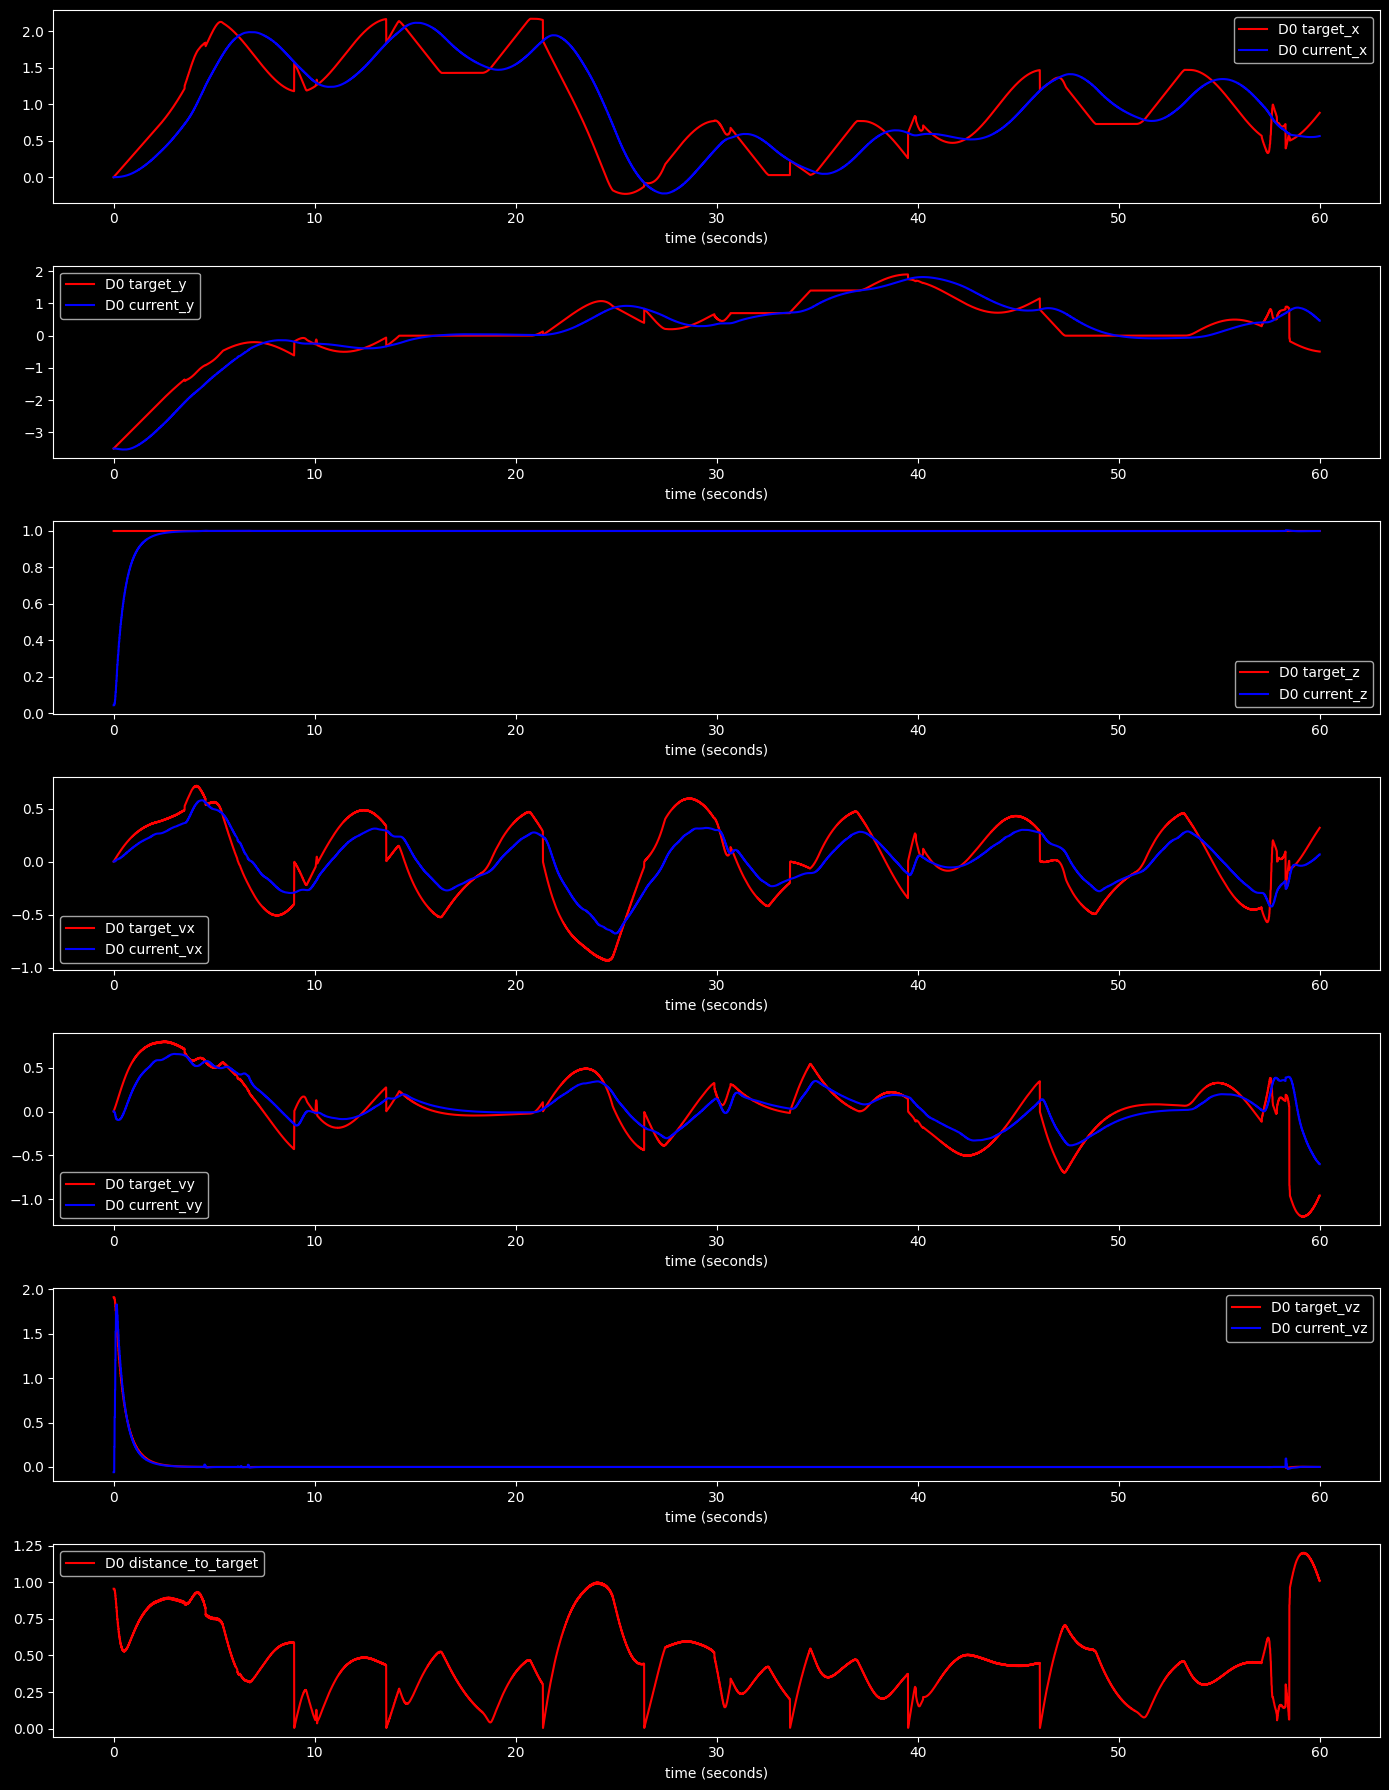

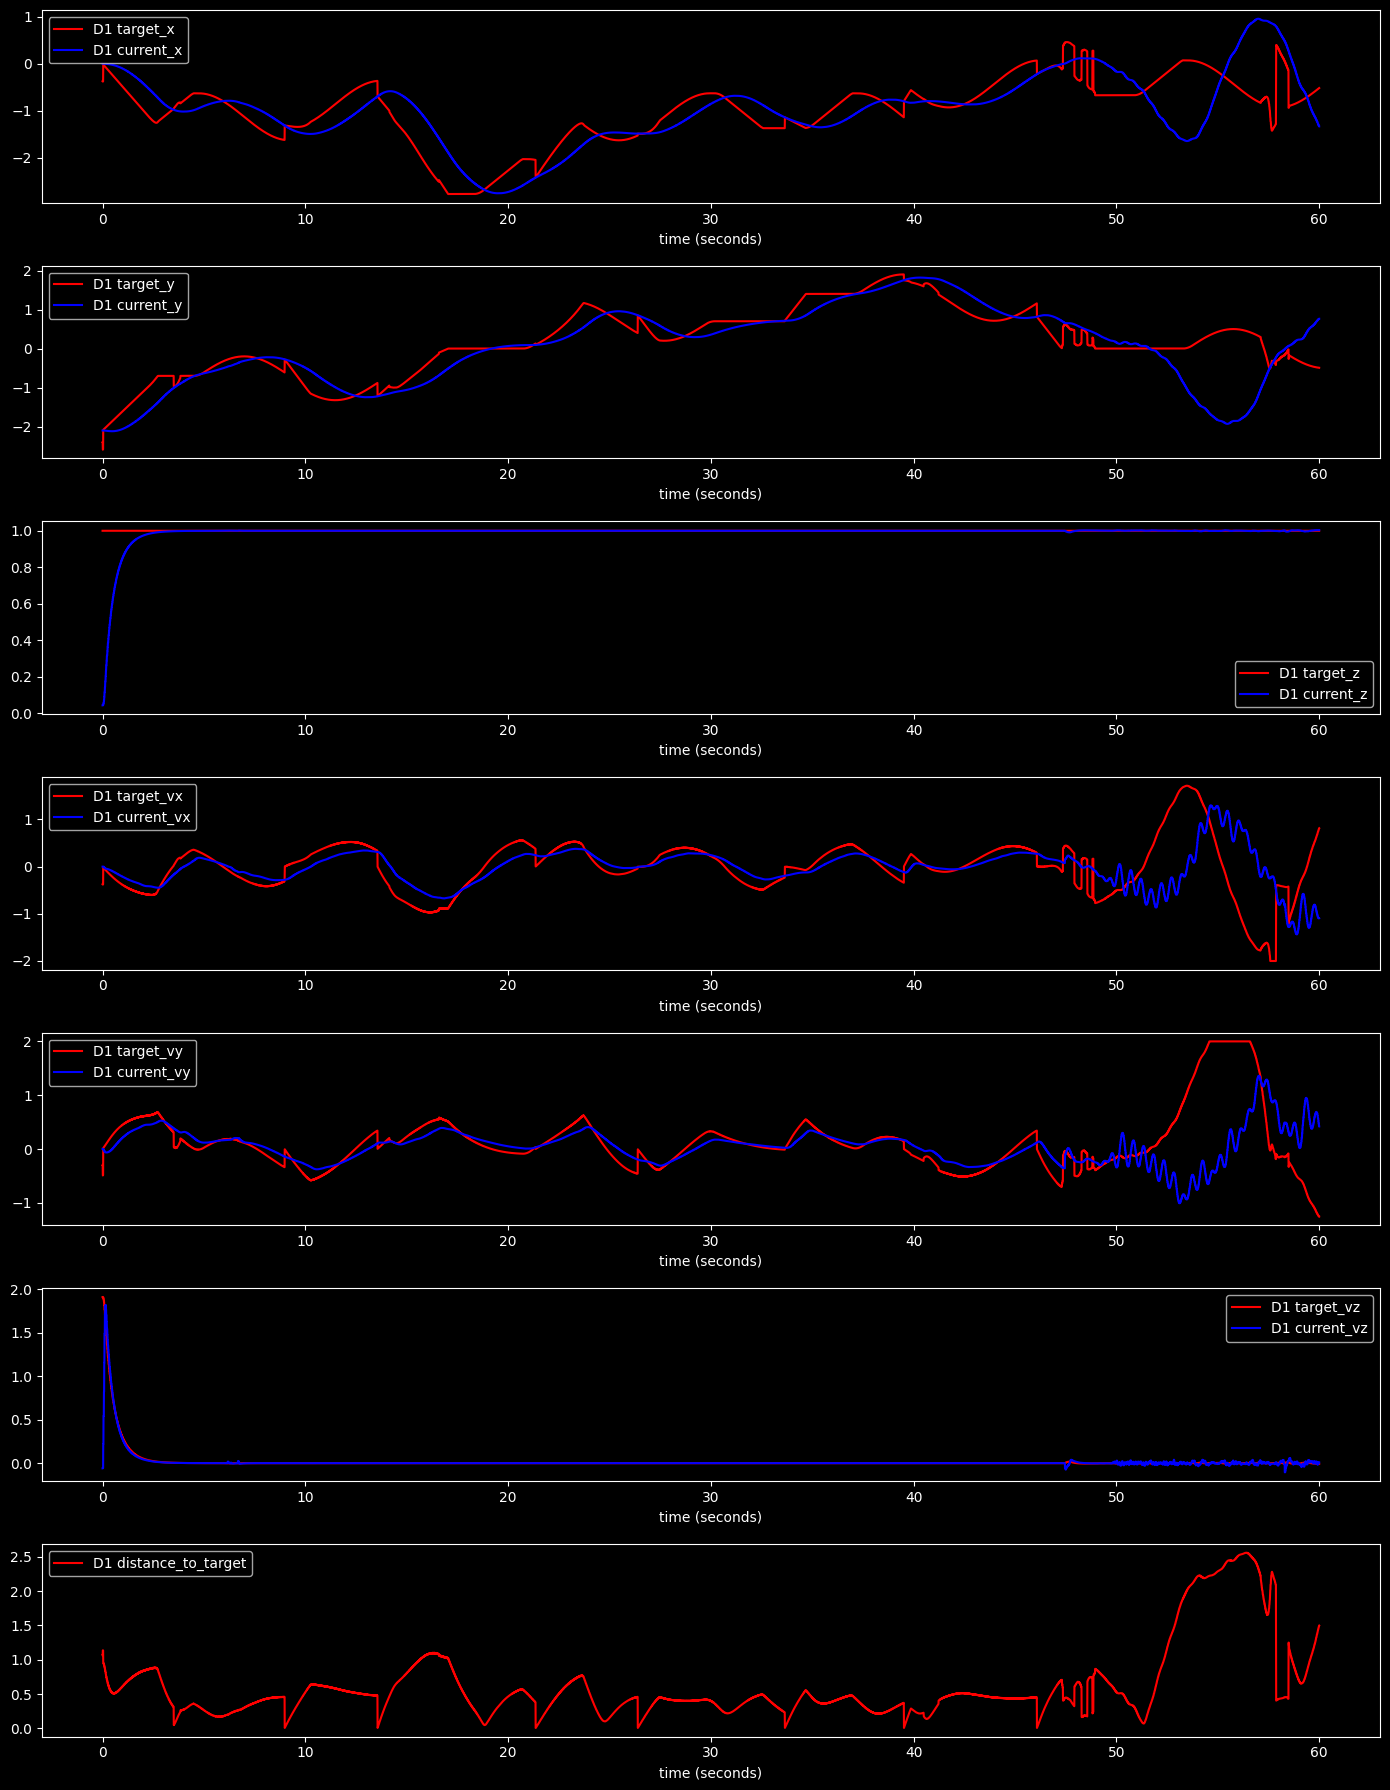

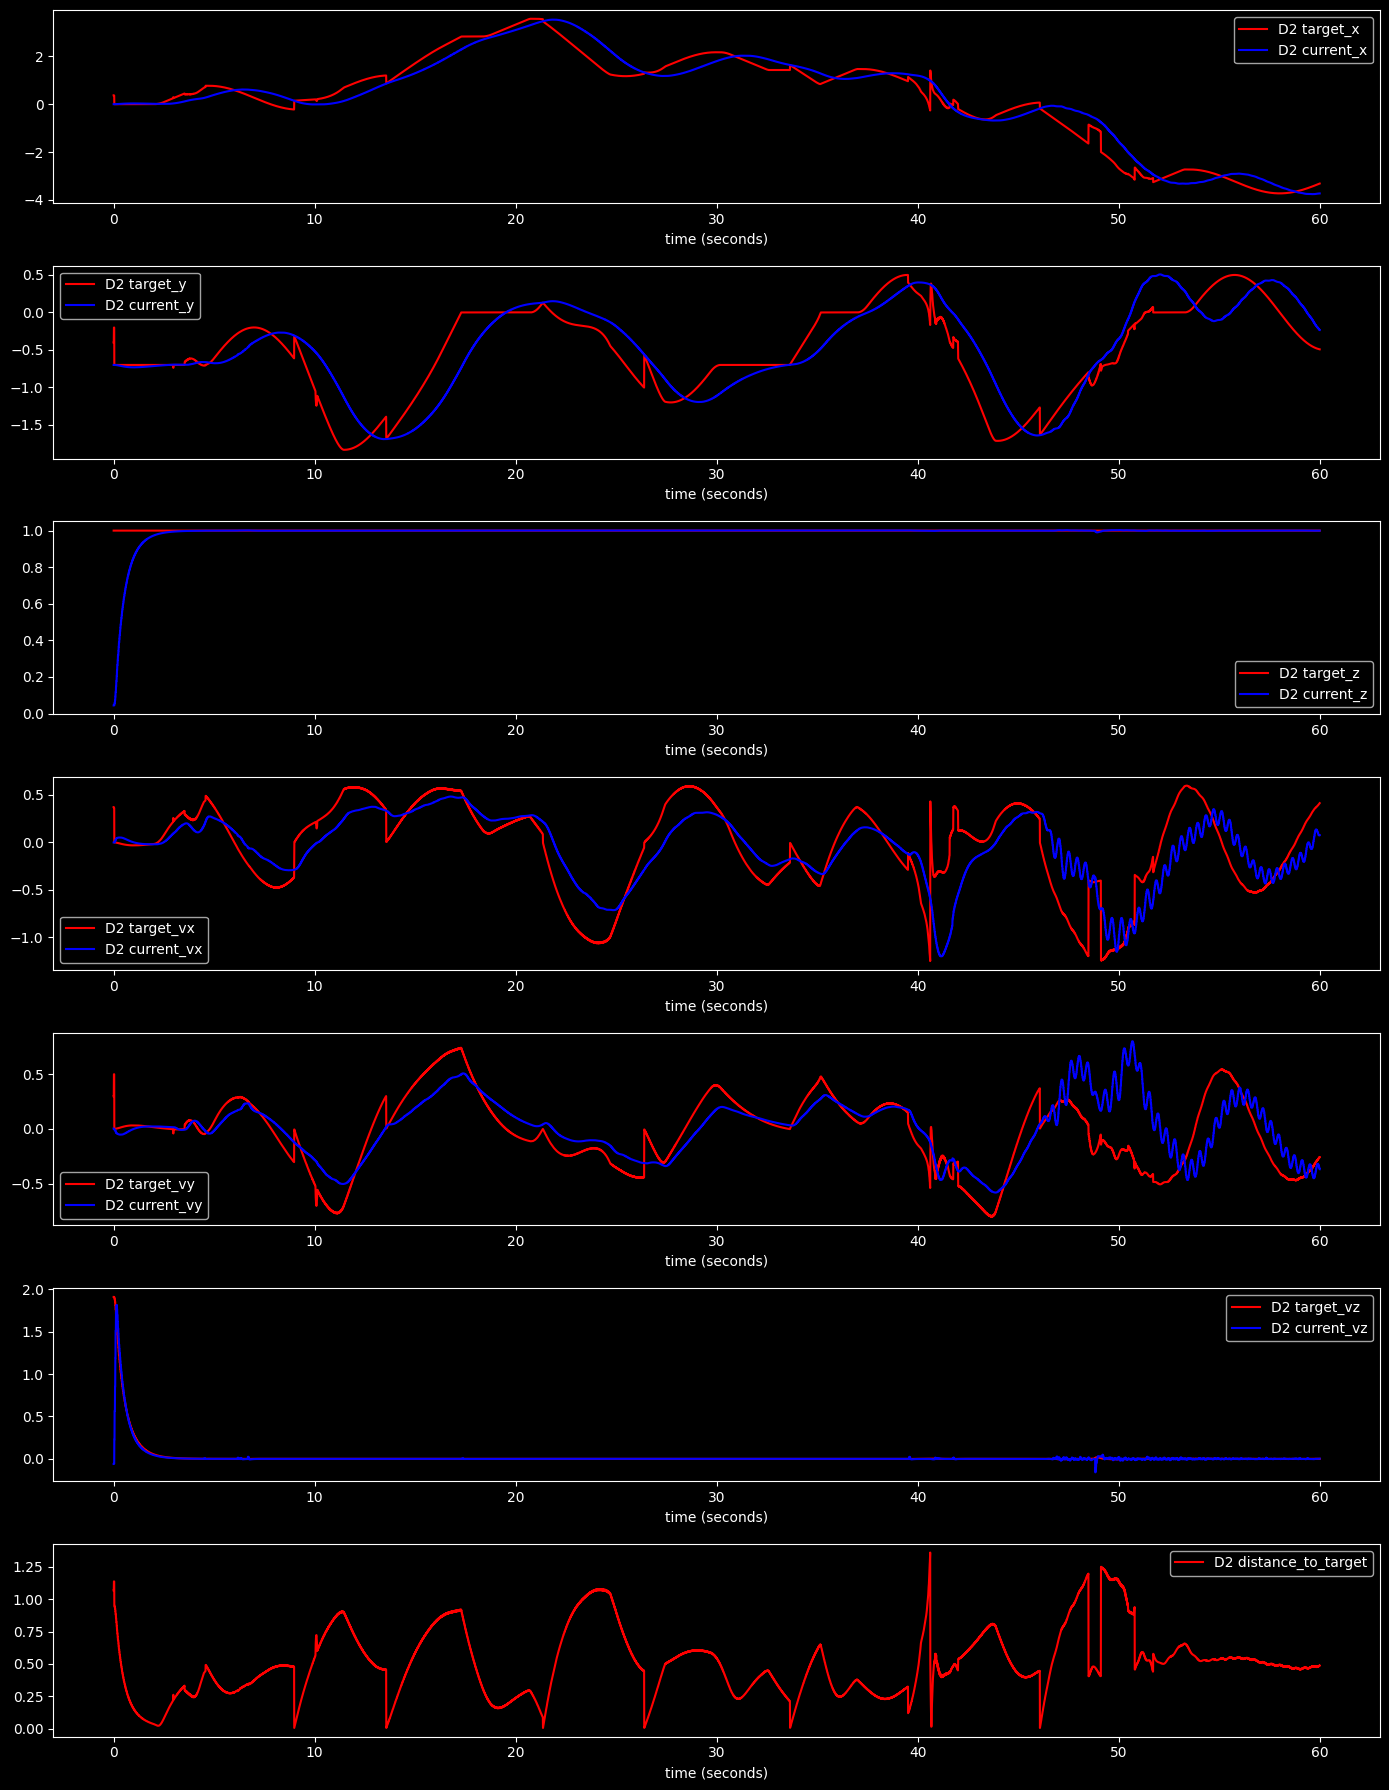

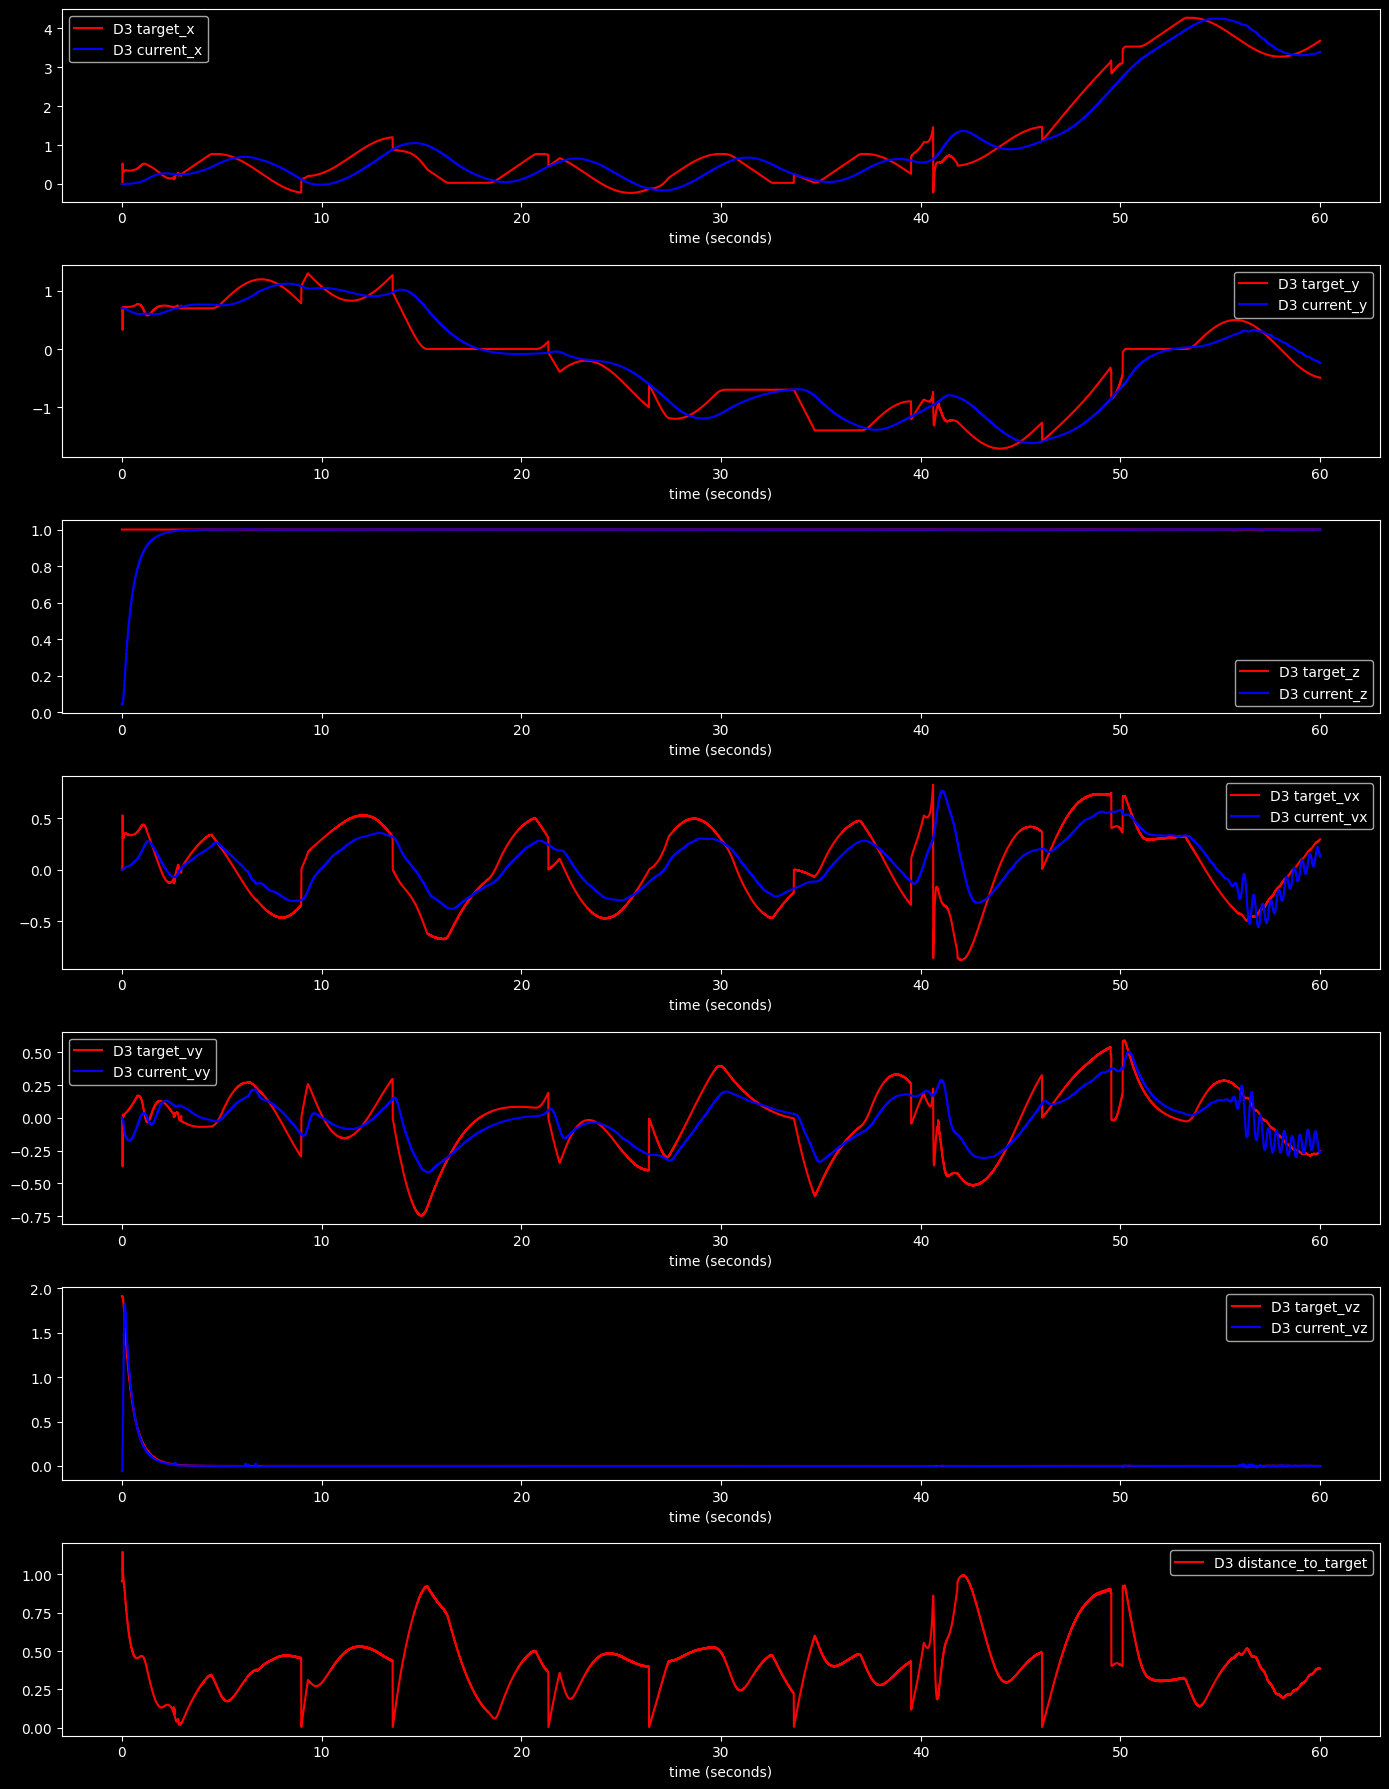

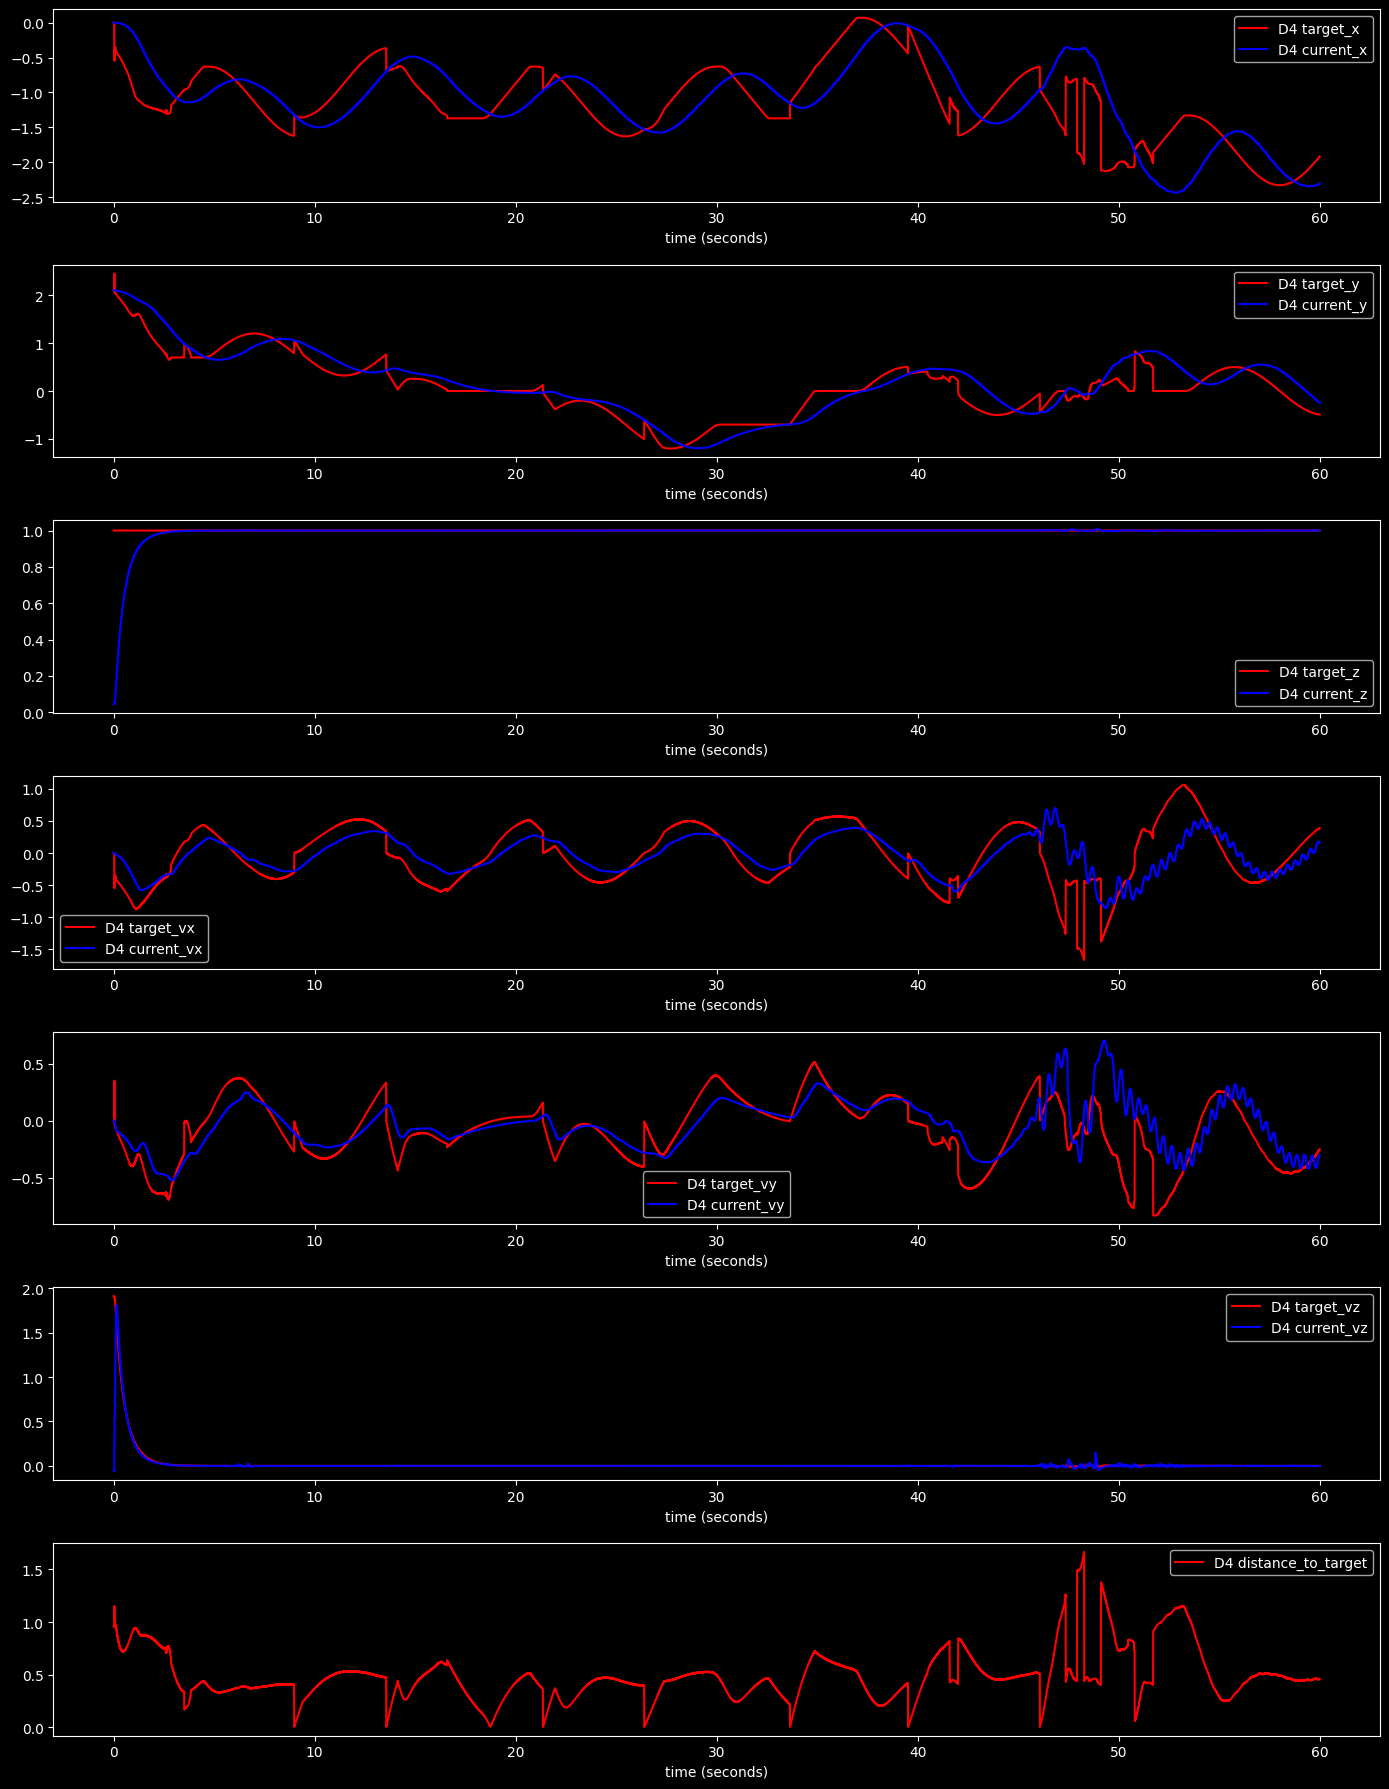

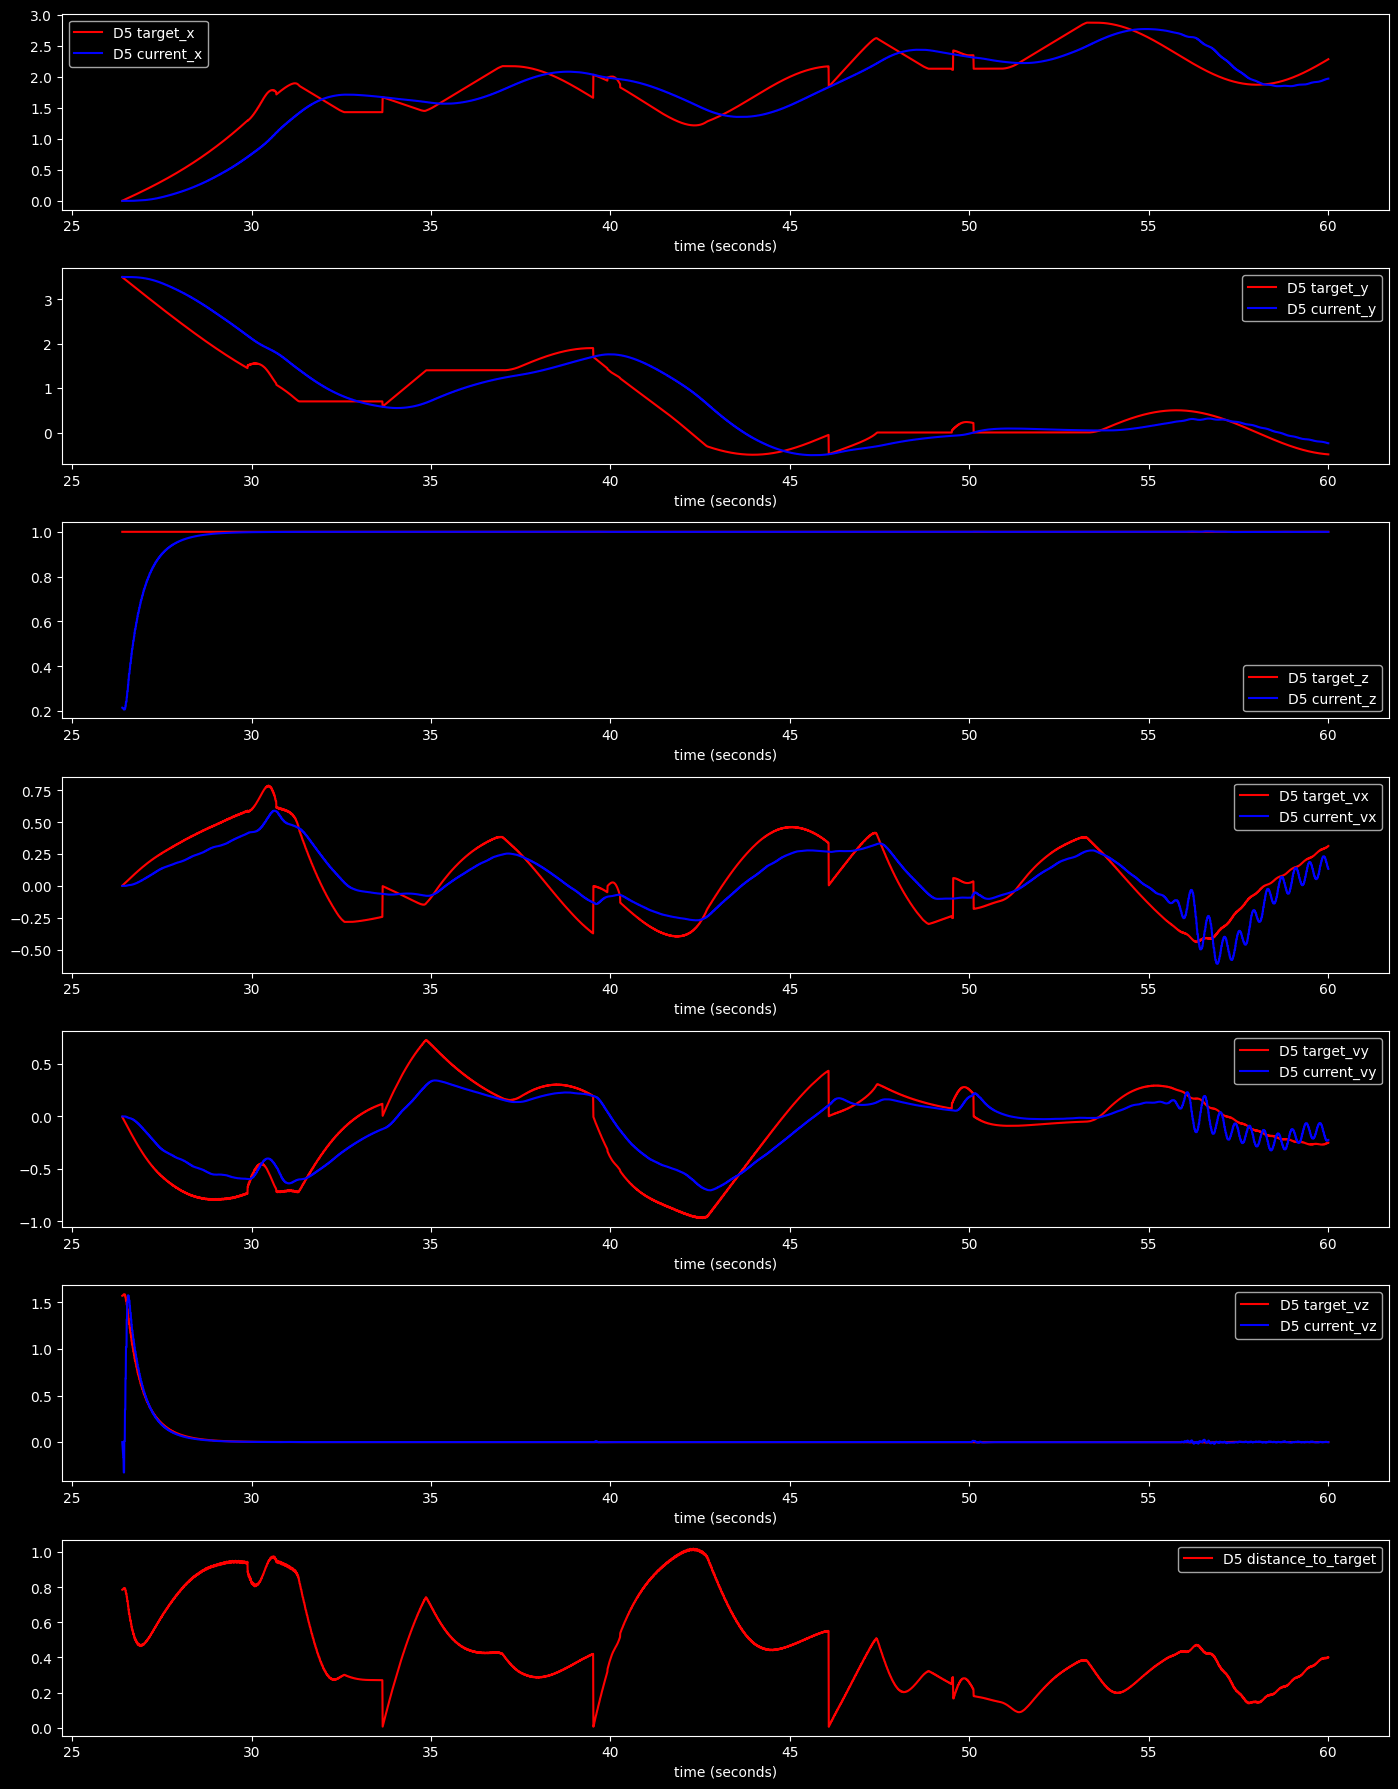

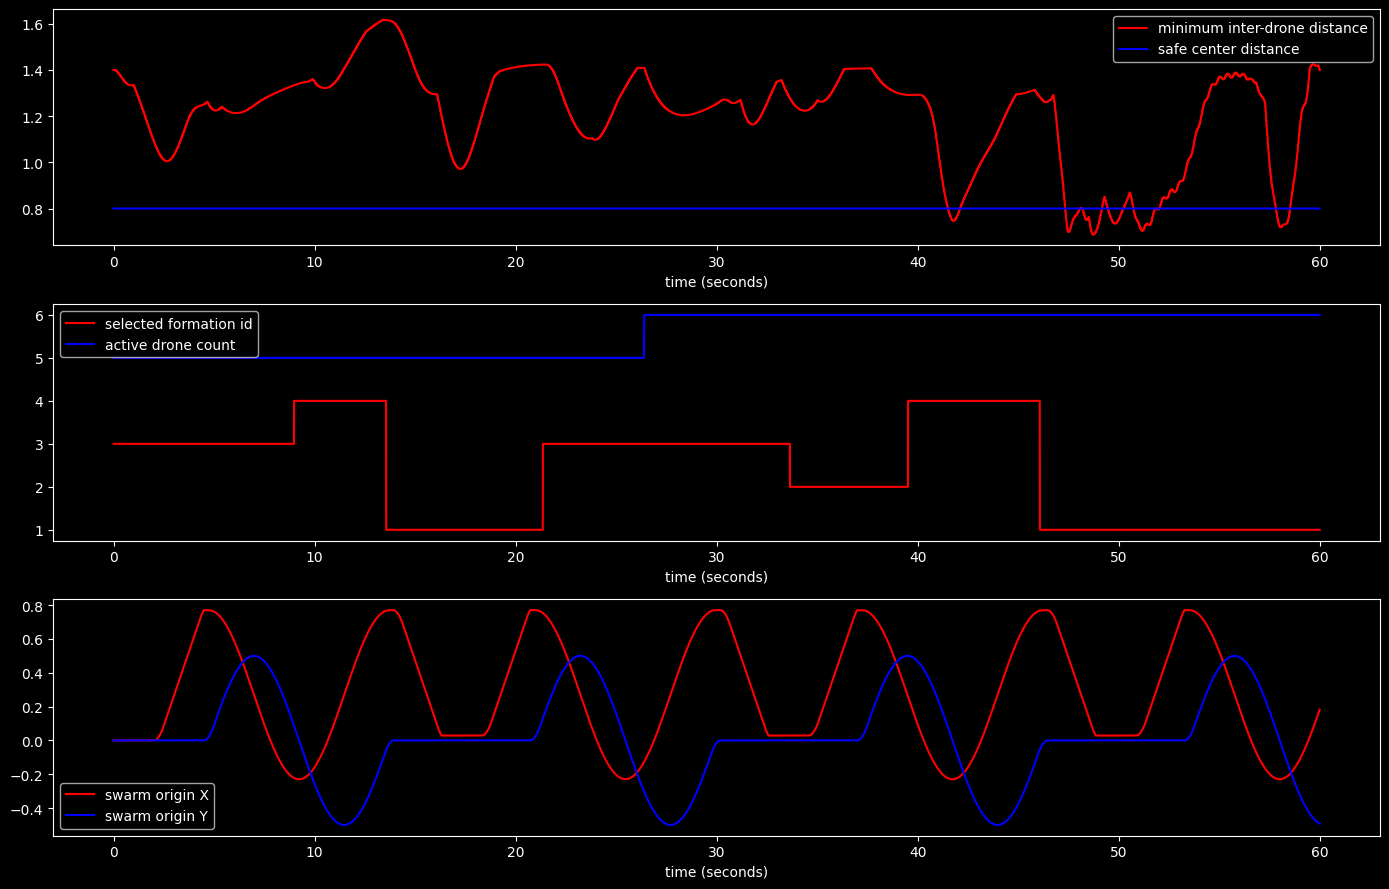

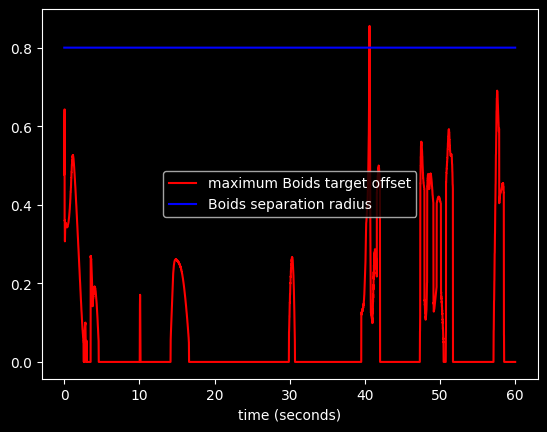

Formations seen: LINE, TRIANGLE, SQUARE, CIRCLE
Drone counts seen: [5, 6]
Minimum inter-drone distance: 0.687
Maximum Boids target offset: 0.855
Done


In [90]:
controllers = {}
drone_plotters = {}
swarm_evidence_plotters = create_swarm_evidence_plotters()
boids_evidence_plotter = create_boids_evidence_plotter()
active_ids_previous_tick = set()
skipped_zero_delta_ticks = 0
formation_id_previous_tick = None
formations_seen = set()
drone_counts_seen = set()
minimum_distance_seen = None
maximum_boids_offset_seen = 0.0
swarm_origin = SwarmOrigin(FORMATION_ORIGIN)
swarm_movement_controller = SwarmMovementController(create_swarm_movements(swarm_origin), SWARM_MOVEMENT_REPEAT)
formation_transition_manager = FormationTransitionManager()

dds = DDS()
dds.start()
dds.subscribe(subscribe_topics_for(MAX_DRONES))

print("Waiting for Godot start")
dds.wait("start")
print("Started")
print(f"Notebook fallback starts at {CURRENT_DRONES} drones; live count comes from DDS topic {CURRENT_DRONES_TOPIC}")
print("Boids collision avoidance is", "enabled" if BOIDS_ENABLED else "disabled")
print("Swarm movement is", "enabled" if SWARM_MOVEMENT_ENABLED else "disabled")

t = Time()
t.start()

try:
    while t.get() < RUN_SECONDS:
        dds.wait("tick")
        delta_t = t.elapsed()
        if delta_t <= MIN_DELTA_T:
            skipped_zero_delta_ticks += 1
            continue

        current_time = t.get()
        swarm_movement_controller.evaluate(delta_t)
        formation_origin = swarm_origin.as_dict()
        drone_count = read_current_drones(dds)
        formation_id = read_formation_id(dds)
        formations_seen.add(formation_id)
        drone_counts_seen.add(drone_count)
        if formation_id != formation_id_previous_tick:
            print(f"Formation: {FORMATION_NAMES[formation_id]}")
            formation_id_previous_tick = formation_id

        active_ids_this_tick = []
        states_this_tick = {}

        for drone_id in range(drone_count):
            if not is_drone_active(dds, drone_id):
                publish_forces(dds, drone_id, (0.0, 0.0, 0.0, 0.0))
                clear_boids_debug(dds, drone_id)
                continue

            active_ids_this_tick.append(drone_id)
            if drone_id not in controllers:
                controllers[drone_id] = Multirotor()
            if drone_id not in drone_plotters:
                drone_plotters[drone_id] = create_drone_plotters(drone_id)

            states_this_tick[drone_id] = read_drone_state(dds, drone_id)

        base_targets = formation_transition_manager.update(
            active_ids_this_tick,
            formation_id,
            formation_origin,
            states_this_tick,
            delta_t,
        )
        avoidance_states_this_tick = states_with_target_intent(states_this_tick, base_targets)
        targets_this_tick, boids_offsets, boids_modes = apply_boids_to_targets(
            base_targets,
            states_this_tick,
            avoidance_states_this_tick,
        )
        max_boids_offset_this_tick = maximum_boids_offset(boids_offsets)
        maximum_boids_offset_seen = max(maximum_boids_offset_seen, max_boids_offset_this_tick)

        for drone_id in active_ids_this_tick:
            state = states_this_tick[drone_id]
            target = targets_this_tick[drone_id]
            base_target = base_targets[drone_id]
            boids_offset = boids_offsets.get(drone_id, zero_vector())
            boids_mode = boids_modes.get(drone_id, BOIDS_MODE_NONE)
            neighbor_count = len(nearby_neighbor_states_for(drone_id, states_this_tick))
            robot = controllers[drone_id]
            robot.set_target(target)

            forces = robot.evaluate(
                delta_t,
                state["z"], state["vz"],
                state["x"], state["vx"],
                state["y"], state["vy"],
                state["roll"], state["roll_rate"],
                state["pitch"], state["pitch_rate"],
            )
            publish_forces(dds, drone_id, forces)
            publish_boids_debug(dds, drone_id, base_target, target, boids_offset, boids_mode, state, neighbor_count)
            append_drone_plots(drone_plotters[drone_id], current_time, robot, state, target)

        min_distance = append_swarm_evidence_plot(
            swarm_evidence_plotters,
            current_time,
            states_this_tick,
            formation_id,
            drone_count,
            formation_origin,
        )
        append_boids_evidence_plot(boids_evidence_plotter, current_time, max_boids_offset_this_tick)
        if min_distance is not None and (minimum_distance_seen is None or min_distance < minimum_distance_seen):
            minimum_distance_seen = min_distance

        active_ids_this_tick_set = set(active_ids_this_tick)
        for removed_drone_id in active_ids_previous_tick - active_ids_this_tick_set:
            publish_forces(dds, removed_drone_id, (0.0, 0.0, 0.0, 0.0))
            clear_boids_debug(dds, removed_drone_id)
            controllers.pop(removed_drone_id, None)

        active_ids_previous_tick = active_ids_this_tick_set

finally:
    stop_all_motors(dds, MAX_DRONES)
    clear_all_boids_debug(dds, MAX_DRONES)
    dds.stop()

for drone_id in sorted(drone_plotters):
    plot_plotter_group(list(drone_plotters[drone_id].values()), figsize=(14, 18))

plot_plotter_group(list(swarm_evidence_plotters.values()), figsize=(14, 9))
plot_plotter_group([boids_evidence_plotter], figsize=(12, 5))

if formations_seen:
    print(f"Formations seen: {format_formation_ids(formations_seen)}")
if drone_counts_seen:
    print(f"Drone counts seen: {sorted(drone_counts_seen)}")
if minimum_distance_seen is not None:
    print(f"Minimum inter-drone distance: {minimum_distance_seen:.3f}")
else:
    print("Minimum inter-drone distance: not available")
print(f"Maximum Boids target offset: {maximum_boids_offset_seen:.3f}")
if skipped_zero_delta_ticks > 0:
    print(f"Skipped {skipped_zero_delta_ticks} zero-delta tick(s)")

print("Done")
